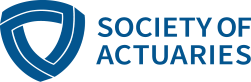

# ✅ 06 Sensitivity and Validation

|                  |                                                                                             |
| ---------------- | ------------------------------------------------------------------------------------------- |
| Title            | 06 Sensitivity and Validation                                                               |
| Case Study       | Climate-Adjusted Mortality for Selected EU Countries                                        |
| Research Project | CC230 Quantifying Mortality and Morbidity Impacts from Climate Risks                       |
| Notebook         | `06_sensitivity_and_validation.ipynb`                                                       |
| Authors          | Carlos Arocha, FSA, SCR                                                                     |
| Sponsor          | Catastrophe and Climate Strategic Research Program, Society of Actuaries Research Institute |
| Date             | `2026-05-11`                                                                                |
| Version          | `v1.0.0`                                                                                    |
| Questions?       | Questions regarding this notebook should be directed to the SOA project contact             |

---

## Purpose

This notebook implements the sensitivity and validation layer for the climate-adjusted mortality case study.

It reads the run configuration and file manifests created by the preceding notebooks, then evaluates the sensitivity of projected mortality impacts to:

- the construction of the composite climate index $C_{t,r}$
- component exclusions in $C_{t,r}$
- selected shocks to $\lambda_{x,r}$
- residual diagnostics and reasonableness checks by country, age, year, and scenario

---

## Conceptual note

Where the weights of $C_{t,r}$ are changed, $\lambda_{x,r}$ is recalibrated against historical residuals. This avoids mixing a climate index calibrated under one definition with projections constructed under another definition.

---

## Inputs

- `CC230-Toolkit/outputs/baseline_parameters_a_xr_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/baseline_parameters_b_x_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/baseline_parameters_k_t_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/climate_parameters_lambda_xr_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/data/processed/climate/C_tr_core_country_annual_combined_era5_cmip6_{SCENARIO}.csv`
- `CC230-Toolkit/outputs/baseline_residuals_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/climate_calibration_panel_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/projected_mortality_baseline_and_climate_adjusted_{PROJECTION_YEARS}.csv`

---

## Outputs

- `CC230-Toolkit/outputs/sensitivity_projection_panel_{PROJECTION_YEARS}.csv`
- `CC230-Toolkit/outputs/sensitivity_summary_by_experiment_{PROJECTION_YEARS}.csv`
- `CC230-Toolkit/outputs/sensitivity_summary_country_year_{PROJECTION_YEARS}.csv`
- `CC230-Toolkit/outputs/sensitivity_summary_country_age_{PROJECTION_YEARS}.csv`
- `CC230-Toolkit/outputs/validation_reasonableness_flags_{PROJECTION_YEARS}.csv`
- `CC230-Toolkit/outputs/validation_reasonableness_flag_summary_{PROJECTION_YEARS}.csv`
- `CC230-Toolkit/outputs/residual_validation_diagnostics_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/residual_validation_correlations_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/c_weight_lambda_sensitivity_parameters_2004_2025_excl_2020_2021.csv`
- `CC230-Toolkit/outputs/sensitivity_validation_metadata.csv`

Report:
- `CC-230-Toolkit/reports/{NOTEBOOK}.html`

---

## Dependencies

This notebook can be run in Google Colab or any compatible Jupyter environment, such as:

* JupyterLab
* Jupyter Notebook
* VS Code with the Jupyter extension
* Anaconda Navigator
* Kaggle Notebooks

The notebook was developed using:

* Python 3.14.5
* Required libraries installed through the setup cell below

---

## Disclaimer
The Jupyter notebooks available through this repository are provided for research, educational, and illustrative purposes only. They are not intended to constitute actuarial advice or to represent production-ready systems without further validation, customization, and governance by the user.

While reasonable efforts have been made to ensure accuracy and consistency, no guarantee is given as to completeness, fitness for a particular purpose, or compliance with applicable actuarial standards or regulatory requirements.

Users are responsible for assessing the suitability of the materials for their specific use cases and for implementing appropriate controls, validation, and documentation prior to any operational use.

---

## License
© 2026 Society of Actuaries. Except where otherwise noted, the textual content of this book is licensed under the Creative Commons Attribution–Noncommercial–Share Alike 4.0 International License (CC BY-NC-SA 4.0). Source code samples, including scripts, notebooks, and code blocks where indicated, are licensed under the MIT License, unless otherwise stated.

---

## Setup and Shared Configuration

In [1]:
# Setup and shared configuration

from pathlib import Path, PureWindowsPath
import json
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import subprocess
import sys

from IPython.display import display

import textwrap

PROJECT_ROOT = Path.cwd().parent.resolve()

if PROJECT_ROOT.parts[-1] != "CC230-Toolkit":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

INTERIM_DATA_PATH = PROJECT_ROOT / "data" / "interim"

run_config_file = INTERIM_DATA_PATH / "run_config.json"
input_manifest_file = INTERIM_DATA_PATH / "input_manifest.csv"
notebook1_output_manifest_file = INTERIM_DATA_PATH / "01_data_ingestion_and_preparation_output_manifest.csv"
notebook2_output_manifest_file = INTERIM_DATA_PATH / "02_climate_features_output_manifest.csv"
notebook3_output_manifest_file = INTERIM_DATA_PATH / "03_baseline_mortality_model_output_manifest.csv"
notebook4_output_manifest_file = INTERIM_DATA_PATH / "04_climate_calibration_output_manifest.csv"
notebook5_output_manifest_file = INTERIM_DATA_PATH / "05_projection_engine_output_manifest.csv"

NOTEBOOK_FILE = PROJECT_ROOT / "notebooks" / "06_sensitivity_and_validation.ipynb"    

required_control_files = {
    "run_config": run_config_file,
    "input_manifest": input_manifest_file,
    "notebook2_output_manifest": notebook2_output_manifest_file,
    "notebook3_output_manifest": notebook3_output_manifest_file,
    "notebook4_output_manifest": notebook4_output_manifest_file,
    "notebook5_output_manifest": notebook5_output_manifest_file,
}

for label, file_path in required_control_files.items():
    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing {label}: {file_path}. "
            "Run the preceding notebooks in sequence: "
            "01_data_ingestion_and_preparation.ipynb, "
            "02_climate_features.ipynb, "
            "03_baseline_mortality_model.ipynb, "
            "04_climate_calibration.ipynb, and"
            "05_projection_engine.ipynb."
        )

with open(run_config_file, "r", encoding="utf-8") as f:
    RUN_CONFIG = json.load(f)

input_manifest = pd.read_csv(input_manifest_file)
notebook1_output_manifest = (
    pd.read_csv(notebook1_output_manifest_file)
    if notebook1_output_manifest_file.exists()
    else pd.DataFrame()
)
notebook2_output_manifest = pd.read_csv(notebook2_output_manifest_file)
notebook3_output_manifest = pd.read_csv(notebook3_output_manifest_file)
notebook4_output_manifest = pd.read_csv(notebook4_output_manifest_file)
notebook5_output_manifest = pd.read_csv(notebook5_output_manifest_file)

print("Loaded control files:")
for file_path in [
    run_config_file,
    input_manifest_file,
    notebook2_output_manifest_file,
    notebook3_output_manifest_file,
    notebook4_output_manifest_file,
    notebook5_output_manifest_file,
]:
    print(" -", PureWindowsPath(file_path).name)

Loaded control files:
 - run_config.json
 - input_manifest.csv
 - 02_climate_features_output_manifest.csv
 - 03_baseline_mortality_model_output_manifest.csv
 - 04_climate_calibration_output_manifest.csv
 - 05_projection_engine_output_manifest.csv


## Settings derived from Notebook 01

All case-study settings are read from `run_config.json`. This keeps scenario, calibration years, projection years, country list, and age range consistent across the notebook suite.

In [2]:
# Settings

DATA_PATH = Path(RUN_CONFIG["data_path"])
RAW_DATA_PATH = Path(RUN_CONFIG["raw_data_path"])
PROCESSED_DATA_PATH = Path(RUN_CONFIG["processed_data_path"])
OUTPUT_PATH = Path(RUN_CONFIG["output_path"])

REPORTS_PATH = PROJECT_ROOT / "reports"

SCENARIO = RUN_CONFIG["scenario"]
COUNTRIES = RUN_CONFIG["countries"]

CALIBRATION_START_YEAR = int(RUN_CONFIG["calibration_start_year"])
CALIBRATION_END_YEAR = int(RUN_CONFIG["calibration_end_year"])
EXCLUDED_CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["excluded_calibration_years"]]
CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["calibration_years"]]
CALIBRATION_YEARS_LABEL = RUN_CONFIG["calibration_years_label"]
N_CALIBRATION_YEARS = int(RUN_CONFIG["n_calibration_years"])

PROJECTION_START_YEAR = int(RUN_CONFIG["projection_start_year"])
PROJECTION_END_YEAR = int(RUN_CONFIG["projection_end_year"])
PROJECTION_YEARS = list(range(PROJECTION_START_YEAR, PROJECTION_END_YEAR + 1))
PROJECTION_YEARS_LABEL = f"{PROJECTION_START_YEAR}_{PROJECTION_END_YEAR}"

AGE_MIN = int(RUN_CONFIG["age_min"])
AGE_MAX = int(RUN_CONFIG["age_max"])
AGE_RANGE_LABEL = RUN_CONFIG["age_range_label"]

# Projection settings
K_PROJECTION_METHOD = "linear_extrapolation_selected_calibration_years"
MIN_PROJECTED_MX = 1e-12
MAX_PROJECTED_MX = 1.0

# Composite index baseline weights used for Notebook 06 sensitivity testing.
# These are set explicitly for the component-exclusion analysis included here.
# The upstream run configuration is retained separately for auditability.
CONFIG_WEIGHT_TEMP_ANOMALY = float(RUN_CONFIG.get("w_temp_anomaly", 0.20))
CONFIG_WEIGHT_EXTREME_HEAT_DAYS = float(RUN_CONFIG.get("w_extreme_heat_days", 0.70))
CONFIG_WEIGHT_HEATWAVE_DURATION = float(RUN_CONFIG.get("w_heatwave_duration", 0.10))

BASE_WEIGHT_TEMP_ANOMALY = 0.20
BASE_WEIGHT_EXTREME_HEAT_DAYS = 0.70
BASE_WEIGHT_HEATWAVE_DURATION = 0.10
BASE_WEIGHT_LABEL = "20_70_10"

if not np.isclose(
    CONFIG_WEIGHT_TEMP_ANOMALY + CONFIG_WEIGHT_EXTREME_HEAT_DAYS + CONFIG_WEIGHT_HEATWAVE_DURATION,
    1.0,
):
    print("⚠️ RUN_CONFIG composite-index weights do not sum to 1.")

if not np.allclose(
    [CONFIG_WEIGHT_TEMP_ANOMALY, CONFIG_WEIGHT_EXTREME_HEAT_DAYS, CONFIG_WEIGHT_HEATWAVE_DURATION],
    [BASE_WEIGHT_TEMP_ANOMALY, BASE_WEIGHT_EXTREME_HEAT_DAYS, BASE_WEIGHT_HEATWAVE_DURATION],
):
    print(
        "⚠️ Notebook 06 is using explicit sensitivity baseline weights "
        f"{BASE_WEIGHT_LABEL}, which differ from the RUN_CONFIG weights "
        f"({CONFIG_WEIGHT_TEMP_ANOMALY:.2f}, {CONFIG_WEIGHT_EXTREME_HEAT_DAYS:.2f}, {CONFIG_WEIGHT_HEATWAVE_DURATION:.2f})."
    )
                                      
# Candidate names for the climate-index column produced by Notebook 02
PREFERRED_C_COLUMNS = [
    "C_tr_core",
    "c_tr_core",
    "C_tr",
    "c_tr",
    "climate_index",
]

# Validation and sensitivity settings.
FLOOR_LAMBDA_AT_ZERO = bool(RUN_CONFIG.get("floor_lambda_at_zero", True))
MIN_OBS_PER_LAMBDA_GROUP = min(8, max(3, N_CALIBRATION_YEARS // 2))
RELATIVE_IMPACT_FLAG_THRESHOLD_PCT = float(RUN_CONFIG.get("relative_impact_flag_threshold_pct", 25.0))
CLIMATE_COMPONENT_FLAG_THRESHOLD = float(RUN_CONFIG.get("climate_component_flag_threshold", np.log(1.25)))

# Notebook 06 output files
k_proj_out = OUTPUT_PATH / f"projected_k_t_{CALIBRATION_YEARS_LABEL}_{PROJECTION_YEARS_LABEL}.csv"
projection_out = OUTPUT_PATH / f"projected_mortality_baseline_and_climate_adjusted_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
impact_summary_out = OUTPUT_PATH / f"projected_mortality_impact_summary_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
country_year_summary_out = OUTPUT_PATH / f"projected_mortality_by_country_year_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"

notebook6_output_manifest_file = INTERIM_DATA_PATH / "06_sensitivity_and_validation_output_manifest.csv"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "notebook": "06_sensitivity_and_validation.ipynb",
    "run_timestamp_utc": datetime.now(UTC).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "scenario": SCENARIO,
    "countries": COUNTRIES,
    "calibration_years": CALIBRATION_YEARS,
    "excluded_calibration_years": EXCLUDED_CALIBRATION_YEARS,
    "projection_start_year": PROJECTION_START_YEAR,
    "projection_end_year": PROJECTION_END_YEAR,
    "age_min": AGE_MIN,
    "age_max": AGE_MAX,
    "k_projection_method": K_PROJECTION_METHOD,
    "lambda_projection_treatment": "lambda_xr is filled for missing values and floored at zero before projection",
    "notebook6_baseline_weight_source": "explicit Notebook 06 sensitivity baseline",
    "notebook6_baseline_weights": {
        "w_temp_anomaly": BASE_WEIGHT_TEMP_ANOMALY,
        "w_extreme_heat_days": BASE_WEIGHT_EXTREME_HEAT_DAYS,
        "w_heatwave_duration": BASE_WEIGHT_HEATWAVE_DURATION,
    },
    "run_config_weights": {
        "w_temp_anomaly": CONFIG_WEIGHT_TEMP_ANOMALY,
        "w_extreme_heat_days": CONFIG_WEIGHT_EXTREME_HEAT_DAYS,
        "w_heatwave_duration": CONFIG_WEIGHT_HEATWAVE_DURATION,
    },
}

## Helper Functions and Input Checks

The helper functions below retrieve input files from the upstream manifests, validate required columns, and register Notebook 06 outputs for downstream use.

In [3]:
# Helper functions

def load_manifest(path, label):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"{label} not found: {path}\n"
            "Run the preceding notebooks in sequence before running Notebook 6."
        )
    manifest = pd.read_csv(path)
    required_cols = {"role", "absolute_path"}
    missing = required_cols - set(manifest.columns)
    if missing:
        raise ValueError(f"{label} is missing required columns: {missing}")
    return manifest

def path_from_manifest(manifest, role, required=True):
    rows = manifest[manifest["role"].astype(str).eq(role)].copy()
    if rows.empty:
        message = f"Role '{role}' not found in manifest."
        if required:
            raise KeyError(message)
        print(f"⚠️ {message}")
        return None

    paths = [Path(p) for p in rows["absolute_path"].dropna().astype(str)]
    existing = [p for p in paths if p.exists()]

    if existing:
        return existing[0]

    if required:
        raise FileNotFoundError(
            f"Role '{role}' was found in the manifest, but the referenced file does not exist.\n"
            f"Candidate paths: {paths}"
        )

    print(f"No existing file found for optional role '{role}'.")
    return paths[0] if paths else None

def register_file(role, path, notes="", required=True):
    path = Path(path)
    try:
        relative_path = str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        relative_path = str(path)

    return {
        "role": role,
        "file_name": path.name,
        "absolute_path": str(path),
        "relative_path": relative_path,
        "exists": path.exists(),
        "required": required,
        "notes": notes,
        "created_by": "06_sensitivity_and_validation.ipynb",
        "run_timestamp_utc": RUN_METADATA["run_timestamp_utc"],
    }

def require_columns(df, cols, label):
    missing = set(cols) - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing required columns: {missing}")

def normalize_mortality_parameter_columns(a_xr, b_x, k_t):
    # Normalize column names produced by Notebook 3 across naming variants.
    a_xr = a_xr.copy()
    b_x = b_x.copy()
    k_t = k_t.copy()

    if "a_xr" not in a_xr.columns and "a_xr_initial" in a_xr.columns:
        a_xr = a_xr.rename(columns={"a_xr_initial": "a_xr"})

    if "age_num" not in a_xr.columns:
        a_xr["age_num"] = pd.to_numeric(a_xr["age"], errors="coerce")

    if "age_num" not in b_x.columns:
        b_x["age_num"] = pd.to_numeric(b_x["age"], errors="coerce")

    require_columns(a_xr, ["country", "age", "age_num", "a_xr"], "a_xr")
    require_columns(b_x, ["age", "b_x"], "b_x")
    require_columns(k_t, ["year", "k_t"], "k_t")

    return a_xr, b_x, k_t

def filter_years(df, years, year_col="year"):
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")
    return df[df[year_col].isin([int(y) for y in years])].copy()

print("Helper functions defined.")

Helper functions defined.


## Load Output Manifests

In [4]:
# Load output manifests from preceding notebooks

notebook2_output_manifest_file = INTERIM_DATA_PATH / "02_climate_features_output_manifest.csv"
notebook3_output_manifest_file = INTERIM_DATA_PATH / "03_baseline_mortality_model_output_manifest.csv"
notebook4_output_manifest_file = INTERIM_DATA_PATH / "04_climate_calibration_output_manifest.csv"
notebook5_output_manifest_file = INTERIM_DATA_PATH / "05_projection_engine_output_manifest.csv"

manifest_2 = load_manifest(notebook2_output_manifest_file, "Notebook 2 output manifest")
manifest_3 = load_manifest(notebook3_output_manifest_file, "Notebook 3 output manifest")
manifest_4 = load_manifest(notebook4_output_manifest_file, "Notebook 4 output manifest")
manifest_5 = load_manifest(notebook5_output_manifest_file, "Notebook 5 output manifest")

print("Manifests loaded:")
for p in [
    notebook2_output_manifest_file,
    notebook3_output_manifest_file,
    notebook4_output_manifest_file,
    notebook5_output_manifest_file,
]:
    print(f"  - {PureWindowsPath(p).name}")

Manifests loaded:
  - 02_climate_features_output_manifest.csv
  - 03_baseline_mortality_model_output_manifest.csv
  - 04_climate_calibration_output_manifest.csv
  - 05_projection_engine_output_manifest.csv


In [5]:
# Input files from manifests

climate_feature_file = path_from_manifest(manifest_2, "climate_index_combined")
a_file = path_from_manifest(manifest_3, "baseline_parameter_a_xr")
b_file = path_from_manifest(manifest_3, "baseline_parameter_b_x")
k_file = path_from_manifest(manifest_3, "baseline_parameter_k_t")
baseline_residuals_file = path_from_manifest(manifest_3, "baseline_residuals")
lambda_file = path_from_manifest(manifest_4, "climate_parameter_lambda_xr")
calibration_panel_file = path_from_manifest(manifest_4, "climate_calibration_panel")
projection_panel_file = path_from_manifest(manifest_5, "projected_mortality_panel")
country_year_projection_file = path_from_manifest(manifest_5, "projected_mortality_country_year_summary")

input_files = pd.DataFrame({
    "input": [
        "climate_feature_file",
        "a_file",
        "b_file",
        "k_file",
        "baseline_residuals_file",
        "lambda_file",
        "calibration_panel_file",
        "projection_panel_file",
        "country_year_projection_file",
    ],
    "path": [
        climate_feature_file,
        a_file,
        b_file,
        k_file,
        baseline_residuals_file,
        lambda_file,
        calibration_panel_file,
        projection_panel_file,
        country_year_projection_file,
    ],
})

input_files["exists"] = input_files["path"].apply(lambda p: Path(p).exists())

if not input_files["exists"].all():
    raise FileNotFoundError("One or more required input files are missing. Review the manifests above.")

## Load Input Data

In [6]:
# Load data

climate = pd.read_csv(climate_feature_file) # type: ignore
a_xr = pd.read_csv(a_file) # type: ignore
b_x = pd.read_csv(b_file) # type: ignore
k_t = pd.read_csv(k_file) # type: ignore
baseline_residuals = pd.read_csv(baseline_residuals_file) # type: ignore
lambda_xr = pd.read_csv(lambda_file) # type: ignore
calibration_panel = pd.read_csv(calibration_panel_file) # type: ignore
projection_panel_base = pd.read_csv(projection_panel_file) # type: ignore
country_year_projection = pd.read_csv(country_year_projection_file) # type: ignore

a_xr, b_x, k_t = normalize_mortality_parameter_columns(a_xr, b_x, k_t)

# Standard filters inherited from Notebook 01

for df_name in ["climate", "a_xr", "baseline_residuals", "lambda_xr", "calibration_panel", "projection_panel_base", "country_year_projection"]:
    df = globals()[df_name]
    if "country" in df.columns:
        globals()[df_name] = df[df["country"].isin(COUNTRIES)].copy()

for df_name in ["a_xr", "b_x", "baseline_residuals", "lambda_xr", "calibration_panel", "projection_panel_base"]:
    df = globals()[df_name]
    if "age_num" in df.columns:
        globals()[df_name] = df[df["age_num"].between(AGE_MIN, AGE_MAX)].copy()
    elif "age" in df.columns:
        globals()[df_name] = df[pd.to_numeric(df["age"], errors="coerce").between(AGE_MIN, AGE_MAX)].copy()

# Use the adopted production convention: floor lambda at zero on read, without holding multiple lambda versions.
lambda_xr["lambda_xr"] = pd.to_numeric(lambda_xr["lambda_xr"], errors="coerce").fillna(0.0).clip(lower=0.0)

print("Loaded input shapes:")
for name in [
    "climate", "a_xr", "b_x", "k_t", "baseline_residuals", "lambda_xr", "calibration_panel", "projection_panel_base"
]:
    print(f"  {name:24s}: {globals()[name].shape}")

Loaded input shapes:
  climate                 : (153, 18)
  a_xr                    : (198, 4)
  b_x                     : (66, 3)
  k_t                     : (20, 2)
  baseline_residuals      : (3960, 9)
  lambda_xr               : (198, 12)
  calibration_panel       : (3960, 15)
  projection_panel_base   : (6138, 18)


## Sensitivity design

The sensitivity tests examine three sources of model sensitivity:

1. alternative weights in the composite heat-related climate index $C_{t,r}$
2. exclusion of components of $C_{t,r}$
3. selected shocks to the climate-sensitivity parameter $\lambda_{x,r}$

The weight sensitivities re-estimate $\lambda_{x,r}$ using the same historical residual structure, so that the climate-index scale and the climate-sensitivity parameter remain internally consistent.

## Model Functions for Sensitivity Testing

In [7]:
# Functions

Z_COLS = {
    "temp_anomaly": "z_temp_anomaly",
    "extreme_heat_days": "z_extreme_heat_days",
    "heatwave_duration": "z_heatwave_duration",
}

require_columns(climate, ["country", "year", "period_type", "scenario", *Z_COLS.values()], "climate")
require_columns(baseline_residuals, ["country", "year", "age", "age_num", "baseline_residual"], "baseline_residuals")
require_columns(lambda_xr, ["country", "age", "age_num", "lambda_xr"], "lambda_xr")

def construct_C_tr(climate_df, w_temp_anomaly, w_extreme_heat_days, w_heatwave_duration):
    weights = np.array([w_temp_anomaly, w_extreme_heat_days, w_heatwave_duration], dtype=float)
    
    out = climate_df.copy()
    out["C_tr"] = (
        weights[0] * out[Z_COLS["temp_anomaly"]]
        + weights[1] * out[Z_COLS["extreme_heat_days"]]
        + weights[2] * out[Z_COLS["heatwave_duration"]]
    )
    out["w_temp_anomaly"] = weights[0]
    out["w_extreme_heat_days"] = weights[1]
    out["w_heatwave_duration"] = weights[2]
    return out

def estimate_lambda_from_residuals(residuals_df, C_hist_df):
    hist_C = C_hist_df[
        C_hist_df["period_type"].eq("historical")
        & C_hist_df["year"].isin(CALIBRATION_YEARS)
    ][["country", "year", "C_tr"]].copy()

    panel = residuals_df.merge(hist_C, on=["country", "year"], how="inner")
    panel = panel.dropna(subset=["baseline_residual", "C_tr"]).copy()

    records = []
    for (country, age, age_num), g in panel.groupby(["country", "age", "age_num"], sort=True):
        n_obs = len(g)
        if n_obs < MIN_OBS_PER_LAMBDA_GROUP or np.isclose(g["C_tr"].var(ddof=0), 0):
            lambda_hat = np.nan
            status = "not_estimated"
        else:
            x = g["C_tr"].astype(float).values
            y = g["baseline_residual"].astype(float).values
            denom = np.sum(x * x)
            lambda_hat = np.nan if np.isclose(denom, 0) else np.sum(x * y) / denom
            status = "estimated"

        records.append({
            "country": country,
            "age": age,
            "age_num": age_num,
            "lambda_xr": lambda_hat,
            "n_obs": n_obs,
            "status": status,
        })

    out = pd.DataFrame(records)
    out["lambda_xr"] = pd.to_numeric(out["lambda_xr"], errors="coerce").fillna(0.0)
    
    return out

def prepare_lambda_for_projection(lambda_df):
    """
    Apply the Notebook 06 production convention for lambda before projection.
    Missing values are filled with zero. If FLOOR_LAMBDA_AT_ZERO is true,
    negative values are floored at zero.
    """
    out = lambda_df.copy()
    require_columns(out, ["country", "age", "age_num", "lambda_xr"], "lambda_df")
    out["lambda_xr"] = pd.to_numeric(out["lambda_xr"], errors="coerce").fillna(0.0)

    if FLOOR_LAMBDA_AT_ZERO:
        out["lambda_xr"] = out["lambda_xr"].clip(lower=0.0)

    return out

def validate_weight_experiments(experiments, tolerance=1e-8):
    """
    Validate that each composite-index weight experiment is non-negative
    and sums to one.
    """
    required = ["experiment_name", "w_temp_anomaly", "w_extreme_heat_days", "w_heatwave_duration"]

    for exp in experiments:
        missing = [key for key in required if key not in exp]
        if missing:
            raise ValueError(f"Experiment definition is missing keys {missing}: {exp}")

        weights = np.array(
            [
                exp["w_temp_anomaly"],
                exp["w_extreme_heat_days"],
                exp["w_heatwave_duration"],
            ],
            dtype=float,
        )

        if np.any(weights < -tolerance):
            raise ValueError(f"Negative weight found in {exp['experiment_name']}: {weights}")

        if not np.isclose(weights.sum(), 1.0, atol=tolerance):
            raise ValueError(
                f"Weights for {exp['experiment_name']} do not sum to 1. "
                f"Sum = {weights.sum():.10f}; weights = {weights}"
            )

    return True


def experiment_code_from_name(experiment_name):
    return str(experiment_name).split("_")[0]

# This function is designed to be flexible for different projection methods, but all methods currently implemented in the toolkit are variations on linear extrapolation.
# The method parameter allows for easy switching between these approaches and can be extended in the future to include more complex projection techniques if desired.

def project_k_t(k_t_df, years, method):
    kt = k_t_df.copy()
    kt["year"] = pd.to_numeric(kt["year"], errors="coerce").astype(int)
    kt = kt[kt["year"].isin(CALIBRATION_YEARS)].sort_values("year")

    if kt.empty:
        raise ValueError("No k_t observations are available for the configured calibration years.")

    years_arr = np.array([int(y) for y in years], dtype=float)

    if method == "K3_flat_last_observed":
        values = np.repeat(float(kt.sort_values("year")["k_t"].iloc[-1]), len(years_arr))

    else:
        if method == "K2_linear_recent_10_years":
            fit_data = kt.tail(min(10, len(kt))).copy()
        else:
            fit_data = kt.copy()

        x = fit_data["year"].astype(float).values
        y = fit_data["k_t"].astype(float).values

        if len(fit_data) < 2 or np.isclose(np.var(x), 0):
            values = np.repeat(float(kt.sort_values("year")["k_t"].iloc[-1]), len(years_arr))
        else:
            slope, intercept = np.polyfit(x, y, 1)
            values = intercept + slope * years_arr

            if method == "K4_damped_linear_full_calibration":
                last_year = float(kt["year"].max())
                last_value = float(kt.loc[kt["year"].idxmax(), "k_t"])
                damping = 0.50
                values = last_value + damping * slope * (years_arr - last_year)

    return pd.DataFrame({
        "year": years_arr.astype(int),
        "k_t_projection": values,
        "k_projection_method": method,
    })

def run_projection_experiment(C_proj_df, lambda_df, k_proj_df, experiment_type, experiment_name):
    climate_proj = C_proj_df[
        C_proj_df["period_type"].eq("projection")
        & C_proj_df["year"].isin(PROJECTION_YEARS)
        & C_proj_df["scenario"].astype(str).eq(str(SCENARIO))
    ][["country", "year", "C_tr"]].copy()

    projection_grid = a_xr[["country", "age", "age_num", "a_xr"]].merge(
        b_x[["age", "b_x"]],
        on="age",
        how="inner",
    )

    projection_grid = projection_grid.merge(
        lambda_df[["country", "age", "age_num", "lambda_xr"]],
        on=["country", "age", "age_num"],
        how="left",
    )
    projection_grid["lambda_xr"] = projection_grid["lambda_xr"].fillna(0.0)
    
    panel = projection_grid.merge(climate_proj, on="country", how="inner")
    panel = panel.merge(k_proj_df[["year", "k_t_projection", "k_projection_method"]], on="year", how="inner")

    panel["log_mx_projected_baseline"] = panel["a_xr"] + panel["b_x"] * panel["k_t_projection"]
    panel["climate_component"] = panel["lambda_xr"] * panel["C_tr"]
    panel["log_mx_projected_climate_adjusted"] = panel["log_mx_projected_baseline"] + panel["climate_component"]

    panel["mx_projected_baseline"] = np.exp(panel["log_mx_projected_baseline"])
    panel["mx_projected_climate_adjusted"] = np.exp(panel["log_mx_projected_climate_adjusted"])
    panel["absolute_mx_impact"] = panel["mx_projected_climate_adjusted"] - panel["mx_projected_baseline"]
    panel["relative_mx_impact"] = panel["mx_projected_climate_adjusted"] / panel["mx_projected_baseline"] - 1.0
    panel["relative_mx_impact_pct"] = 100.0 * panel["relative_mx_impact"]

    panel["experiment_type"] = experiment_type
    panel["experiment_name"] = experiment_name
    return panel

print("Sensitivity functions defined.")

Sensitivity functions defined.


In [8]:
# Define sensitivity experiments

BASE_C_WEIGHT_DICT = {
    "w_temp_anomaly": BASE_WEIGHT_TEMP_ANOMALY,
    "w_extreme_heat_days": BASE_WEIGHT_EXTREME_HEAT_DAYS,
    "w_heatwave_duration": BASE_WEIGHT_HEATWAVE_DURATION,
}

def exclude_and_renormalize(base_weights, excluded_key):
    """
    Set one component weight to zero and re-normalize the remaining
    components to sum to one.
    """
    if excluded_key not in base_weights:
        raise KeyError(f"Unknown component weight: {excluded_key}")

    weights = {key: float(value) for key, value in base_weights.items()}
    weights[excluded_key] = 0.0

    remaining_total = sum(weights.values())

    if remaining_total <= 0:
        raise ValueError("At least one non-excluded component must retain positive weight.")

    return {key: value / remaining_total for key, value in weights.items()}

WEIGHT_EXPERIMENTS = [
    {
        "experiment_type": "C_weights",
        "experiment_name": "C1_base_20_70_10",
        "excluded_component": "none",
        **BASE_C_WEIGHT_DICT,
    },
    {
        "experiment_type": "C_weights",
        "experiment_name": "C2_equal_weights_33_33_33",
        "excluded_component": "none",
        "w_temp_anomaly":      1 / 3,
        "w_extreme_heat_days": 1 / 3,
        "w_heatwave_duration": 1 / 3,
    },
    {
        "experiment_type": "C_weights",
        "experiment_name": "C3_duration_heavy_25_35_40",
        "excluded_component": "none",
        "w_temp_anomaly":      0.25,
        "w_extreme_heat_days": 0.35,
        "w_heatwave_duration": 0.40,
    },
    {
        "experiment_type": "C_weights",
        "experiment_name": "C4_temp_heavy_60_25_15",
        "excluded_component": "none",
        "w_temp_anomaly":      0.60,
        "w_extreme_heat_days": 0.25,
        "w_heatwave_duration": 0.15,
    },
]

COMPONENT_EXCLUSION_EXPERIMENTS = [
    {
        "experiment_type": "component_exclusion",
        "experiment_name": "E1_base_20_70_10",
        "excluded_component": "none",
        **BASE_C_WEIGHT_DICT,
    },
    {
        "experiment_type": "component_exclusion",
        "experiment_name": "E2_excl_temp_anomaly",
        "excluded_component": "temp_anomaly",
        **exclude_and_renormalize(BASE_C_WEIGHT_DICT, "w_temp_anomaly"),
    },
    {
        "experiment_type": "component_exclusion",
        "experiment_name": "E3_excl_extreme_heat_days",
        "excluded_component": "extreme_heat_days",
        **exclude_and_renormalize(BASE_C_WEIGHT_DICT, "w_extreme_heat_days"),
    },
    {
        "experiment_type": "component_exclusion",
        "experiment_name": "E4_excl_heatwave_duration",
        "excluded_component": "heatwave_duration",
        **exclude_and_renormalize(BASE_C_WEIGHT_DICT, "w_heatwave_duration"),
    },
]

LAMBDA_SHOCKS = [
    {
        "experiment_type": "lambda_shock",
        "experiment_name": "L1_lambda_50pct",
        "excluded_component": "not_applicable",
        "lambda_factor": 0.50,
    },
    {
        "experiment_type": "lambda_shock",
        "experiment_name": "L2_lambda_100pct",
        "excluded_component": "not_applicable",
        "lambda_factor": 1.00,
    },
    {
        "experiment_type": "lambda_shock",
        "experiment_name": "L3_lambda_150pct",
        "excluded_component": "not_applicable",
        "lambda_factor": 1.50,
    },
    {
        "experiment_type": "lambda_shock",
        "experiment_name": "L4_lambda_200pct",
        "excluded_component": "not_applicable",
        "lambda_factor": 2.00,
    },
]

validate_weight_experiments(WEIGHT_EXPERIMENTS + COMPONENT_EXCLUSION_EXPERIMENTS)

ALL_EXPERIMENTS = WEIGHT_EXPERIMENTS + COMPONENT_EXCLUSION_EXPERIMENTS + LAMBDA_SHOCKS

for exp in ALL_EXPERIMENTS:
    exp["experiment_code"] = experiment_code_from_name(exp["experiment_name"])

experiment_definitions = pd.DataFrame(ALL_EXPERIMENTS)

print("Weight experiments:")
display(pd.DataFrame(WEIGHT_EXPERIMENTS))

print("Component exclusion experiments:")
display(pd.DataFrame(COMPONENT_EXCLUSION_EXPERIMENTS))

print("Lambda shocks:")
display(pd.DataFrame(LAMBDA_SHOCKS))

print("Experiments defined.")
print(f"Expected number of experiments: {len(ALL_EXPERIMENTS)}")


Weight experiments:


,experiment_type,experiment_name,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration,experiment_code
0,C_weights,C1_base_20_70_10,none,0.200000,0.700000,0.100000,C1
1,C_weights,C2_equal_weights_33_33_33,none,0.333333,0.333333,0.333333,C2
2,C_weights,C3_duration_heavy_25_35_40,none,0.250000,0.350000,0.400000,C3
3,C_weights,C4_temp_heavy_60_25_15,none,0.600000,0.250000,0.150000,C4


Component exclusion experiments:


,experiment_type,experiment_name,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration,experiment_code
0,component_exclusion,E1_base_20_70_10,none,0.200000,0.700000,0.100000,E1
1,component_exclusion,E2_excl_temp_anomaly,temp_anomaly,0.000000,0.875000,0.125000,E2
2,component_exclusion,E3_excl_extreme_heat_days,extreme_heat_days,0.666667,0.000000,0.333333,E3
3,component_exclusion,E4_excl_heatwave_duration,heatwave_duration,0.222222,0.777778,0.000000,E4


Lambda shocks:


,experiment_type,experiment_name,excluded_component,lambda_factor,experiment_code
0,lambda_shock,L1_lambda_50pct,not_applicable,0.5,L1
1,lambda_shock,L2_lambda_100pct,not_applicable,1.0,L2
2,lambda_shock,L3_lambda_150pct,not_applicable,1.5,L3
3,lambda_shock,L4_lambda_200pct,not_applicable,2.0,L4


Experiments defined.
Expected number of experiments: 12


## Run Sensitivity Experiments

In [9]:
# Sensitivity experiments

experiment_panels = []

base_C = construct_C_tr(
    climate,
    BASE_WEIGHT_TEMP_ANOMALY,
    BASE_WEIGHT_EXTREME_HEAT_DAYS,
    BASE_WEIGHT_HEATWAVE_DURATION,
)

base_k_proj = project_k_t(k_t, PROJECTION_YEARS, "K1_linear_full_calibration")

def append_experiment_metadata(panel, exp):
    panel = panel.copy()
    panel["experiment_type"] = exp["experiment_type"]
    panel["experiment_name"] = exp["experiment_name"]
    panel["experiment_code"] = exp.get("experiment_code", experiment_code_from_name(exp["experiment_name"]))
    panel["excluded_component"] = exp.get("excluded_component", "none")
    panel["w_temp_anomaly"] = exp.get("w_temp_anomaly", BASE_WEIGHT_TEMP_ANOMALY)
    panel["w_extreme_heat_days"] = exp.get("w_extreme_heat_days", BASE_WEIGHT_EXTREME_HEAT_DAYS)
    panel["w_heatwave_duration"] = exp.get("w_heatwave_duration", BASE_WEIGHT_HEATWAVE_DURATION)
    panel["lambda_factor"] = float(exp.get("lambda_factor", 1.0))
    return panel

# 1. Composite climate-index weight experiments
for exp in WEIGHT_EXPERIMENTS:
    C_exp = construct_C_tr(
        climate,
        exp["w_temp_anomaly"],
        exp["w_extreme_heat_days"],
        exp["w_heatwave_duration"],
    )

    lambda_exp = estimate_lambda_from_residuals(baseline_residuals, C_exp)
    lambda_exp = prepare_lambda_for_projection(lambda_exp)

    panel = run_projection_experiment(
        C_exp,
        lambda_exp,
        base_k_proj,
        exp["experiment_type"],
        exp["experiment_name"],
    )

    experiment_panels.append(append_experiment_metadata(panel, exp))

# 2. Component-exclusion tests
# Convention: set the excluded component to zero, re-normalize the remaining
# baseline weights, then recalibrate lambda_xr under the revised C_{t,r}
for exp in COMPONENT_EXCLUSION_EXPERIMENTS:
    C_exp = construct_C_tr(
        climate,
        exp["w_temp_anomaly"],
        exp["w_extreme_heat_days"],
        exp["w_heatwave_duration"],
    )

    lambda_exp = estimate_lambda_from_residuals(baseline_residuals, C_exp)
    lambda_exp = prepare_lambda_for_projection(lambda_exp)

    panel = run_projection_experiment(
        C_exp,
        lambda_exp,
        base_k_proj,
        exp["experiment_type"],
        exp["experiment_name"],
    )

    experiment_panels.append(append_experiment_metadata(panel, exp))

# 3. Lambda shock experiments
# Convention: hold C_{t,r} at the 20/70/10 baseline and shock lambda_xr.
for exp in LAMBDA_SHOCKS:
    lambda_exp = lambda_xr.copy()
    lambda_exp["lambda_xr"] = pd.to_numeric(lambda_exp["lambda_xr"], errors="coerce").fillna(0.0)
    lambda_exp["lambda_xr"] = lambda_exp["lambda_xr"] * float(exp["lambda_factor"])
    lambda_exp = prepare_lambda_for_projection(lambda_exp)

    panel = run_projection_experiment(
        base_C,
        lambda_exp,
        base_k_proj,
        exp["experiment_type"],
        exp["experiment_name"],
    )

    experiment_panels.append(append_experiment_metadata(panel, exp))

sensitivity_panel = pd.concat(experiment_panels, ignore_index=True)

n_experiments_observed = sensitivity_panel[["experiment_type", "experiment_name"]].drop_duplicates().shape[0]
n_experiments_expected = len(ALL_EXPERIMENTS)

if n_experiments_observed != n_experiments_expected:
    raise ValueError(
        f"Expected {n_experiments_expected} sensitivity experiments, "
        f"but found {n_experiments_observed}."
    )

rows_by_experiment = (
    sensitivity_panel
    .groupby(["experiment_type", "experiment_name"], as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)

if rows_by_experiment["rows"].nunique() > 1:
    print("⚠️ Row counts differ across experiments. Review missing country-age-year combinations.")
    display(rows_by_experiment)

expected_rows = int(rows_by_experiment["rows"].iloc[0] * n_experiments_expected)

print("Sensitivity panel rows:", len(sensitivity_panel))
print("Expected sensitivity panel rows:", expected_rows)
print("Experiments:", n_experiments_observed)
display(rows_by_experiment)


Sensitivity panel rows: 73656
Expected sensitivity panel rows: 73656
Experiments: 12


,experiment_type,experiment_name,rows
0,C_weights,C1_base_20_70_10,6138
1,C_weights,C2_equal_weights_33_33_33,6138
2,C_weights,C3_duration_heavy_25_35_40,6138
3,C_weights,C4_temp_heavy_60_25_15,6138
4,component_exclusion,E1_base_20_70_10,6138
5,component_exclusion,E2_excl_temp_anomaly,6138
6,component_exclusion,E3_excl_extreme_heat_days,6138
7,component_exclusion,E4_excl_heatwave_duration,6138
8,lambda_shock,L1_lambda_50pct,6138
9,lambda_shock,L2_lambda_100pct,6138


## Sensitivity Summaries

In [10]:
# Summaries

comparison_keys = ["country", "age", "age_num", "year"]

baseline_reference_by_type = {
    "C_weights": "C1_base_20_70_10",
    "component_exclusion": "E1_base_20_70_10",
    "lambda_shock": "L2_lambda_100pct",
}

delta_metric_cols = [
    "relative_mx_impact_pct",
    "climate_component",
    "mx_projected_climate_adjusted",
]

delta_frames = []

for experiment_type, baseline_name in baseline_reference_by_type.items():
    group_panel = sensitivity_panel[
        sensitivity_panel["experiment_type"].eq(experiment_type)
    ].copy()

    if group_panel.empty:
        continue

    baseline_panel = group_panel[
        group_panel["experiment_name"].eq(baseline_name)
    ][comparison_keys + delta_metric_cols].copy()

    if baseline_panel.empty:
        print(f"⚠️ No baseline found for experiment_type={experiment_type}: {baseline_name}")
        for col in delta_metric_cols:
            group_panel[f"baseline_{col}"] = np.nan
            group_panel[f"delta_vs_baseline_{col}"] = np.nan
    else:
        baseline_panel = baseline_panel.rename(
            columns={col: f"baseline_{col}" for col in delta_metric_cols}
        )

        group_panel = group_panel.merge(
            baseline_panel,
            on=comparison_keys,
            how="left",
        )

        for col in delta_metric_cols:
            group_panel[f"delta_vs_baseline_{col}"] = (
                group_panel[col] - group_panel[f"baseline_{col}"]
            )

    delta_frames.append(group_panel)

sensitivity_panel = pd.concat(delta_frames, ignore_index=True)

summary_by_experiment = (
    sensitivity_panel
    .groupby(["experiment_type", "experiment_name", "experiment_code"], as_index=False)
    .agg(
        mean_C_tr=("C_tr", "mean"),
        mean_lambda_xr=("lambda_xr", "mean"),
        mean_climate_component=("climate_component", "mean"),
        mean_relative_mx_impact=("relative_mx_impact", "mean"),
        mean_relative_mx_impact_pct=("relative_mx_impact_pct", "mean"),
        median_relative_mx_impact_pct=("relative_mx_impact_pct", "median"),
        min_relative_mx_impact_pct=("relative_mx_impact_pct", "min"),
        max_relative_mx_impact_pct=("relative_mx_impact_pct", "max"),
        mean_delta_vs_baseline_relative_mx_impact_pct=("delta_vs_baseline_relative_mx_impact_pct", "mean"),
        mean_delta_vs_baseline_climate_component=("delta_vs_baseline_climate_component", "mean"),
        rows=("relative_mx_impact_pct", "size"),
    )
    .merge(
        experiment_definitions[
            [
                "experiment_type",
                "experiment_name",
                "experiment_code",
                "excluded_component",
                "w_temp_anomaly",
                "w_extreme_heat_days",
                "w_heatwave_duration",
                "lambda_factor",
            ]
        ],
        on=["experiment_type", "experiment_name", "experiment_code"],
        how="left",
    )
    .sort_values(["experiment_type", "experiment_code", "experiment_name"])
    .reset_index(drop=True)
)

summary_country_year = (
    sensitivity_panel
    .groupby(["experiment_type", "experiment_name", "experiment_code", "country", "year"], as_index=False)
    .agg(
        mean_C_tr=("C_tr", "mean"),
        mean_climate_component=("climate_component", "mean"),
        mean_relative_mx_impact=("relative_mx_impact", "mean"),
        mean_relative_mx_impact_pct=("relative_mx_impact_pct", "mean"),
        median_relative_mx_impact_pct=("relative_mx_impact_pct", "median"),
        min_relative_mx_impact_pct=("relative_mx_impact_pct", "min"),
        max_relative_mx_impact_pct=("relative_mx_impact_pct", "max"),
        mean_delta_vs_baseline_relative_mx_impact_pct=("delta_vs_baseline_relative_mx_impact_pct", "mean"),
        mean_delta_vs_baseline_climate_component=("delta_vs_baseline_climate_component", "mean"),
    )
    .sort_values(["experiment_type", "experiment_code", "country", "year"])
    .reset_index(drop=True)
)

summary_country_age = (
    sensitivity_panel
    .groupby(["experiment_type", "experiment_name", "experiment_code", "country", "age", "age_num"], as_index=False)
    .agg(
        mean_C_tr=("C_tr", "mean"),
        mean_lambda_xr=("lambda_xr", "mean"),
        mean_climate_component=("climate_component", "mean"),
        mean_relative_mx_impact=("relative_mx_impact", "mean"),
        mean_relative_mx_impact_pct=("relative_mx_impact_pct", "mean"),
        median_relative_mx_impact_pct=("relative_mx_impact_pct", "median"),
        min_relative_mx_impact_pct=("relative_mx_impact_pct", "min"),
        max_relative_mx_impact_pct=("relative_mx_impact_pct", "max"),
        mean_delta_vs_baseline_relative_mx_impact_pct=("delta_vs_baseline_relative_mx_impact_pct", "mean"),
        mean_delta_vs_baseline_climate_component=("delta_vs_baseline_climate_component", "mean"),
    )
    .sort_values(["experiment_type", "experiment_code", "country", "age_num"])
    .reset_index(drop=True)
)

component_exclusion_delta_summary = (
    summary_by_experiment[
        summary_by_experiment["experiment_type"].eq("component_exclusion")
    ]
    .copy()
    .sort_values("experiment_code")
    .reset_index(drop=True)
)

print("Sensitivity summaries compiled.")

print("Sensitivity summary by experiment:")
display(summary_by_experiment)

print("Component-exclusion delta summary:")
display(component_exclusion_delta_summary)

print("Country-year sensitivity summary:")
display(summary_country_year.head())


Sensitivity summaries compiled.
Sensitivity summary by experiment:


,experiment_type,experiment_name,experiment_code,mean_C_tr,mean_lambda_xr,mean_climate_component,mean_relative_mx_impact,mean_relative_mx_impact_pct,median_relative_mx_impact_pct,min_relative_mx_impact_pct,max_relative_mx_impact_pct,mean_delta_vs_baseline_relative_mx_impact_pct,mean_delta_vs_baseline_climate_component,rows,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration,lambda_factor
0,C_weights,C1_base_20_70_10,C1,3.333883,0.010317,0.029450,0.031095,3.109498,0.0,-3.292972,36.560427,0.000000,0.000000,6138,none,0.200000,0.700000,0.100000,NaN
1,C_weights,C2_equal_weights_33_33_33,C2,3.088586,0.010283,0.027358,0.028867,2.886745,0.0,-1.717051,35.611473,-0.222754,-0.002092,6138,none,0.333333,0.333333,0.333333,NaN
2,C_weights,C3_duration_heavy_25_35_40,C3,3.357736,0.009949,0.028873,0.030535,3.053536,0.0,-0.749034,36.772440,-0.055962,-0.000577,6138,none,0.250000,0.350000,0.400000,NaN
3,C_weights,C4_temp_heavy_60_25_15,C4,2.243660,0.010668,0.020445,0.021362,2.136175,0.0,-4.535092,28.832150,-0.973323,-0.009005,6138,none,0.600000,0.250000,0.150000,NaN
4,component_exclusion,E1_base_20_70_10,E1,3.333883,0.010317,0.029450,0.031095,3.109498,0.0,-3.292972,36.560427,0.000000,0.000000,6138,none,0.200000,0.700000,0.100000,NaN
5,component_exclusion,E2_excl_temp_anomaly,E2,3.906251,0.009169,0.030899,0.032651,3.265083,0.0,-1.844372,36.050787,0.155585,0.001449,6138,temp_anomaly,0.000000,0.875000,0.125000,NaN
6,component_exclusion,E3_excl_extreme_heat_days,E3,2.157353,0.009684,0.018069,0.018831,1.883130,0.0,-2.927112,26.961213,-1.226369,-0.011381,6138,extreme_heat_days,0.666667,0.000000,0.333333,NaN
7,component_exclusion,E4_excl_heatwave_duration,E4,3.217288,0.010471,0.028764,0.030325,3.032474,0.0,-4.402178,35.262707,-0.077025,-0.000686,6138,heatwave_duration,0.222222,0.777778,0.000000,NaN
8,lambda_shock,L1_lambda_50pct,L1,3.333883,0.005158,0.014725,0.015127,1.512658,0.0,-1.660268,16.859072,-1.596840,-0.014725,6138,not_applicable,NaN,NaN,NaN,0.5
9,lambda_shock,L2_lambda_100pct,L2,3.333883,0.010317,0.029450,0.031095,3.109498,0.0,-3.292972,36.560427,0.000000,0.000000,6138,not_applicable,NaN,NaN,NaN,1.0


Component-exclusion delta summary:


,experiment_type,experiment_name,experiment_code,mean_C_tr,mean_lambda_xr,mean_climate_component,mean_relative_mx_impact,mean_relative_mx_impact_pct,median_relative_mx_impact_pct,min_relative_mx_impact_pct,max_relative_mx_impact_pct,mean_delta_vs_baseline_relative_mx_impact_pct,mean_delta_vs_baseline_climate_component,rows,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration,lambda_factor
0,component_exclusion,E1_base_20_70_10,E1,3.333883,0.010317,0.029450,0.031095,3.109498,0.0,-3.292972,36.560427,0.000000,0.000000,6138,none,0.200000,0.700000,0.100000,NaN
1,component_exclusion,E2_excl_temp_anomaly,E2,3.906251,0.009169,0.030899,0.032651,3.265083,0.0,-1.844372,36.050787,0.155585,0.001449,6138,temp_anomaly,0.000000,0.875000,0.125000,NaN
2,component_exclusion,E3_excl_extreme_heat_days,E3,2.157353,0.009684,0.018069,0.018831,1.883130,0.0,-2.927112,26.961213,-1.226369,-0.011381,6138,extreme_heat_days,0.666667,0.000000,0.333333,NaN
3,component_exclusion,E4_excl_heatwave_duration,E4,3.217288,0.010471,0.028764,0.030325,3.032474,0.0,-4.402178,35.262707,-0.077025,-0.000686,6138,heatwave_duration,0.222222,0.777778,0.000000,NaN


Country-year sensitivity summary:


,experiment_type,experiment_name,experiment_code,country,year,mean_C_tr,mean_climate_component,mean_relative_mx_impact,mean_relative_mx_impact_pct,median_relative_mx_impact_pct,min_relative_mx_impact_pct,max_relative_mx_impact_pct,mean_delta_vs_baseline_relative_mx_impact_pct,mean_delta_vs_baseline_climate_component
0,C_weights,C1_base_20_70_10,C1,ES,2030,3.335649,0.003773,0.003832,0.383224,0.0,0.0,6.191311,0.0,0.0
1,C_weights,C1_base_20_70_10,C1,ES,2031,3.176872,0.003593,0.003647,0.364710,0.0,0.0,5.888098,0.0,0.0
2,C_weights,C1_base_20_70_10,C1,ES,2032,3.509484,0.003970,0.004035,0.403524,0.0,0.0,6.524276,0.0,0.0
3,C_weights,C1_base_20_70_10,C1,ES,2033,3.485678,0.003943,0.004007,0.400742,0.0,0.0,6.478615,0.0,0.0
4,C_weights,C1_base_20_70_10,C1,ES,2034,4.777604,0.005404,0.005526,0.552625,0.0,0.0,8.985040,0.0,0.0


## Plots Experiment Outputs

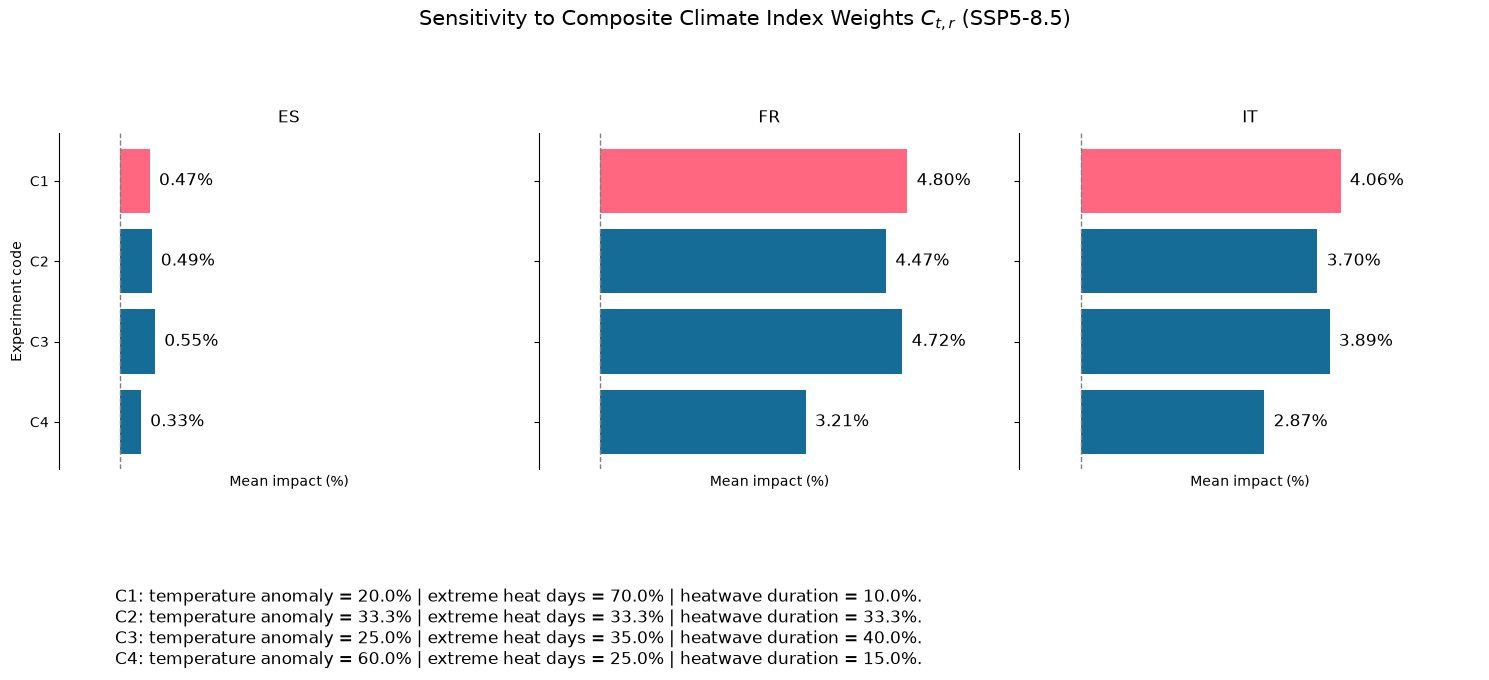

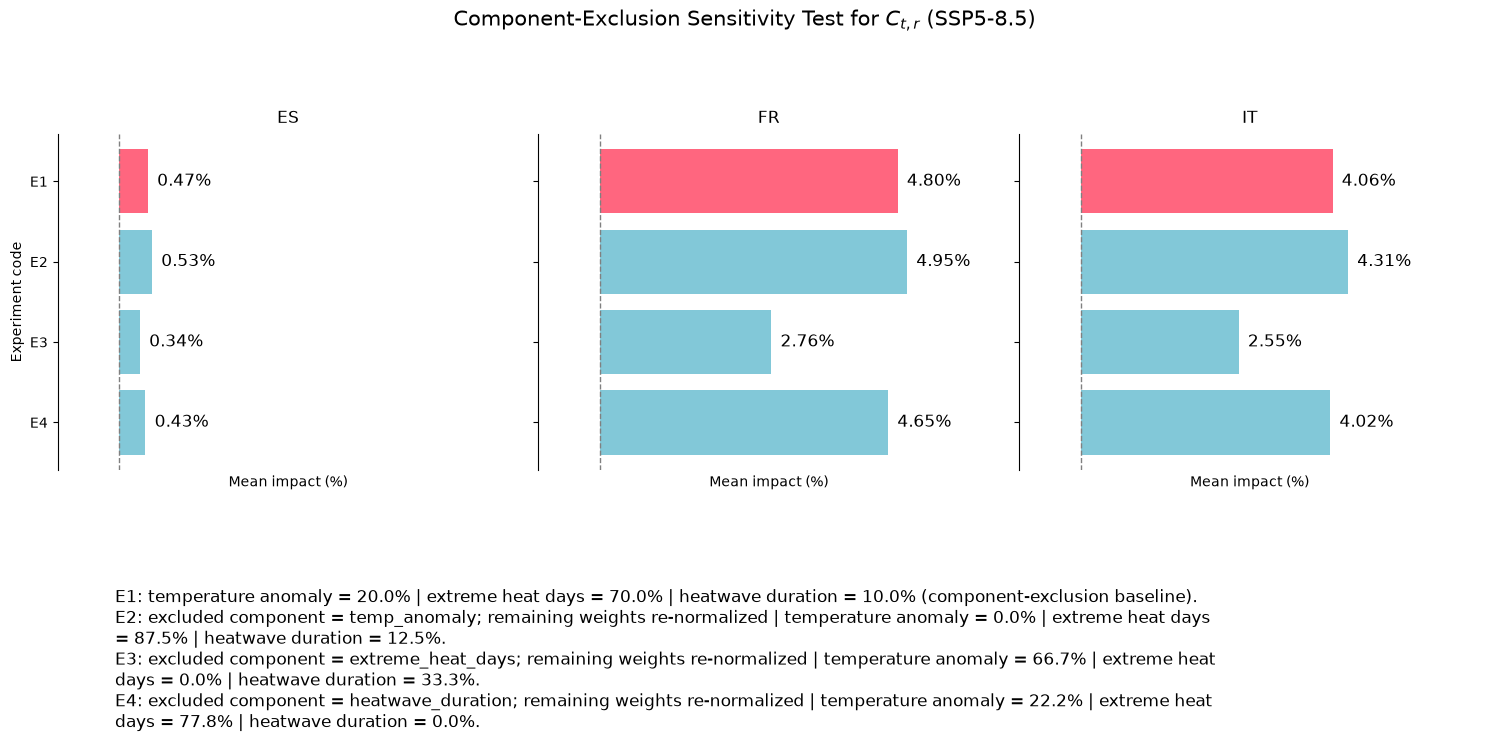

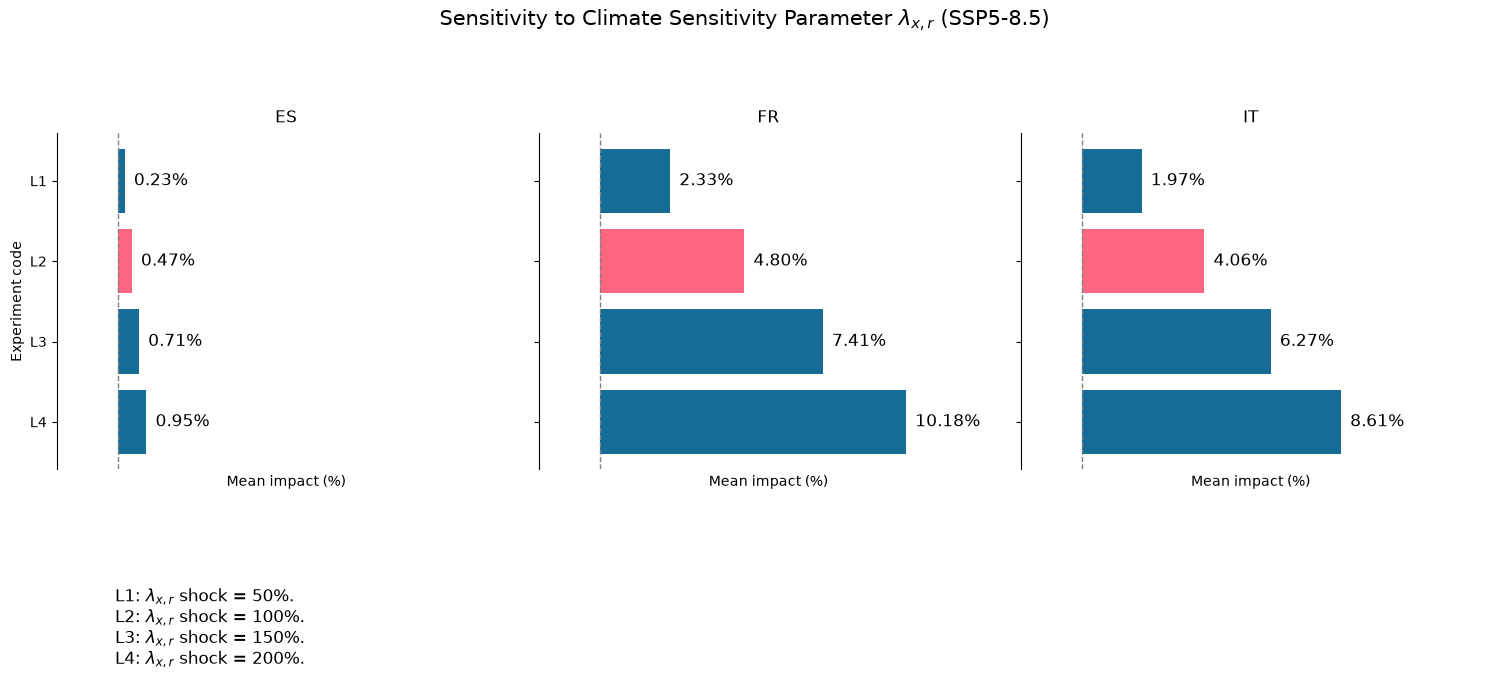

In [11]:
# Experiment outputs

COUNTRIES_TO_PLOT = COUNTRIES

COUNTRY_COL = "country"
EXPERIMENT_NAME_COL = "experiment_name"

df = sensitivity_panel.copy()

if "relative_mx_impact_pct" in df.columns:
    IMPACT_COL = "relative_mx_impact_pct"
elif "mean_relative_mx_impact_pct" in df.columns:
    IMPACT_COL = "mean_relative_mx_impact_pct"
else:
    raise ValueError(
        "Expected either 'relative_mx_impact_pct' or "
        "'mean_relative_mx_impact_pct' in sensitivity_panel."
    )

required_cols = [
    COUNTRY_COL,
    "experiment_type",
    "experiment_code",
    EXPERIMENT_NAME_COL,
    IMPACT_COL,
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[df[COUNTRY_COL].isin(COUNTRIES_TO_PLOT)].copy()
df[IMPACT_COL] = pd.to_numeric(df[IMPACT_COL], errors="coerce")
df = df.dropna(subset=[IMPACT_COL]).copy()

summary = (
    df
    .groupby(
        [COUNTRY_COL, "experiment_type", "experiment_code", EXPERIMENT_NAME_COL],
        as_index=False
    )
    .agg(
        mean_impact_pct=(IMPACT_COL, "mean"),
        mean_delta_vs_baseline_impact_pct=("delta_vs_baseline_relative_mx_impact_pct", "mean"),
    )
    .merge(
        experiment_definitions[
            [
                "experiment_type",
                "experiment_code",
                "experiment_name",
                "excluded_component",
                "w_temp_anomaly",
                "w_extreme_heat_days",
                "w_heatwave_duration",
                "lambda_factor",
            ]
        ],
        on=["experiment_type", "experiment_code", "experiment_name"],
        how="left",
    )
)

experiment_group_map = {
    "C_weights": "weights",
    "component_exclusion": "component_exclusion",
    "lambda_shock": "lambda",
}

summary["experiment_group"] = summary["experiment_type"].map(experiment_group_map).fillna("other")

summary = summary[
    summary["experiment_group"].isin(["weights", "component_exclusion", "lambda"])
].copy()

def pct_weight(value):
    return f"{100.0 * float(value):.1f}%"

def describe_experiment(row):
    group = row["experiment_group"]

    if group in ["weights", "component_exclusion"]:
        weight_text = (
            f"temperature anomaly = {pct_weight(row['w_temp_anomaly'])} | "
            f"extreme heat days = {pct_weight(row['w_extreme_heat_days'])} | "
            f"heatwave duration = {pct_weight(row['w_heatwave_duration'])}"
        )

        if group == "component_exclusion":
            excluded = str(row.get("excluded_component", "none"))
            if excluded == "none":
                return weight_text + " (component-exclusion baseline)"
            return f"excluded component = {excluded}; remaining weights re-normalized | {weight_text}"

        return weight_text

    if group == "lambda":
        return rf"$\lambda_{{x,r}}$ shock = {100.0 * float(row['lambda_factor']):.0f}%"

    return str(row[EXPERIMENT_NAME_COL])

summary["experiment_description"] = summary.apply(describe_experiment, axis=1)

COLOR_BLUE = "#00608E"
COLOR_CORAL = "#ff5974"
COLOR_TEAL = "#77c4d5"

COLOR_WEIGHTS = COLOR_BLUE
COLOR_COMPONENT_EXCLUSION = COLOR_TEAL
COLOR_BASELINE = COLOR_CORAL
COLOR_LAMBDA = COLOR_BLUE

def is_baseline_experiment(row):
    baseline_names = {
        "weights": "C1_base_20_70_10",
        "component_exclusion": "E1_base_20_70_10",
        "lambda": "L2_lambda_100pct",
    }
    return str(row[EXPERIMENT_NAME_COL]) == baseline_names.get(row["experiment_group"], "")

def plot_sensitivity_group(group_name, title, value_col="mean_impact_pct"):

    plot_data = summary[summary["experiment_group"].eq(group_name)].copy()

    if plot_data.empty:
        print(f"No data available for {group_name}.")
        return

    experiment_order = (
        plot_data[
            ["experiment_code", EXPERIMENT_NAME_COL, "experiment_description"]
        ]
        .drop_duplicates()
        .sort_values("experiment_code")
        .reset_index(drop=True)
    )

    experiment_order["plot_order"] = np.arange(len(experiment_order))

    max_abs = max(abs(plot_data[value_col]).max(), 1)

    x_min = min(0, plot_data[value_col].min()) - 0.20 * max_abs
    x_max = max(0, plot_data[value_col].max()) + 0.30 * max_abs

    n_countries = len(COUNTRIES_TO_PLOT)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_countries,
        figsize=(5 * n_countries, 5.5),
        sharey=True
    )

    if n_countries == 1:
        axes = [axes]

    for ax, country in zip(axes, COUNTRIES_TO_PLOT):

        country_data = (
            plot_data[plot_data[COUNTRY_COL].eq(country)]
            .merge(
                experiment_order[["experiment_code", "plot_order"]],
                on="experiment_code",
                how="right"
            )
            .sort_values("plot_order")
            .copy()
        )

        y_positions = np.arange(len(experiment_order))
        values = country_data[value_col]

        bar_colors = []
        for _, row in country_data.iterrows(): # type: ignore
            if is_baseline_experiment(row):
                bar_colors.append(COLOR_BASELINE)
            elif group_name == "component_exclusion":
                bar_colors.append(COLOR_COMPONENT_EXCLUSION)
            else:
                bar_colors.append(COLOR_WEIGHTS if group_name == "weights" else COLOR_LAMBDA)

        bars = ax.barh(
            y_positions,
            values,
            color=bar_colors,
            alpha=0.92
        )

        ax.axvline(0, linestyle="--", linewidth=1.0, color="gray")
        ax.set_title(country, fontsize=12, pad=8)
        ax.set_xlabel("Mean impact (%)", fontsize=10)
        ax.set_xlim(x_min, x_max)

        ax.tick_params(
            axis="x",
            bottom=False,
            labelbottom=False
        )

        ax.grid(False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)

        label_offset = 0.03 * max_abs

        for bar, value in zip(bars, values):

            if pd.isna(value):
                continue

            y = bar.get_y() + bar.get_height() / 2

            ax.text(
                value + label_offset if value >= 0 else value - label_offset,
                y,
                f"{value:.2f}%",
                va="center",
                ha="left" if value >= 0 else "right",
                fontsize=12
            )

    axes[0].set_yticks(np.arange(len(experiment_order)))
    axes[0].set_yticklabels(experiment_order["experiment_code"])
    axes[0].invert_yaxis()
    axes[0].set_ylabel("Experiment code", fontsize=10)

    fig.suptitle(title, fontsize=15, y=1.02)

    caption_lines = []

    for _, row in experiment_order.iterrows(): # type: ignore
        caption_lines.append(
            textwrap.fill(
                f"{row['experiment_code']}: {row['experiment_description']}.",
                width=120
            )
        )

    caption = "\n".join(caption_lines)

    fig.text(
        0.08,
        -0.03,
        caption,
        ha="left",
        va="top",
        fontsize=12,
        linespacing=1.25
    )

    plt.tight_layout(rect=[0.0, 0.12, 1.0, 0.93]) # type: ignore
    plt.show()

    print("")

    fig.savefig(
        OUTPUT_PATH / f"sensitivity_{group_name}_{SCENARIO}.svg",
        dpi=300,
        bbox_inches="tight"
    )

scenario_title = SCENARIO.upper().replace("_", "-", 1).replace("_", ".")

plot_sensitivity_group(
    group_name="weights",
    title=fr"Sensitivity to Composite Climate Index Weights $C_{{t,r}}$ ({scenario_title})"
)

plot_sensitivity_group(
    group_name="component_exclusion",
    title=fr"Component-Exclusion Sensitivity Test for $C_{{t,r}}$ ({scenario_title})"
)

plot_sensitivity_group(
    group_name="lambda",
    title=fr"Sensitivity to Climate Sensitivity Parameter $\lambda_{{x,r}}$ ({scenario_title})"
)


## Residual analysis and reasonableness checks

Residual analysis uses the calibration panel produced by Notebook 04. Reasonableness checks use the base projection panel produced by Notebook 05 and identify values that should be reviewed before report use.

In [12]:
# Residual analysis

resid = calibration_panel.copy()

# filter ES, FR, and IT
resid = resid[resid["country"].isin(COUNTRIES_TO_PLOT)]

if "residual_after_climate" not in resid.columns:
    if {"baseline_residual", "lambda_xr", "C_tr"}.issubset(resid.columns):
        resid["residual_after_climate"] = resid["baseline_residual"] - resid["lambda_xr"] * resid["C_tr"]
    else:
        raise ValueError("Calibration panel does not contain residual_after_climate or the columns needed to derive it.")

require_columns(resid, ["country", "year", "age", "age_num", "baseline_residual", "residual_after_climate"], "calibration_panel")

residual_validation = (
    resid
    .groupby(["country", "year"], as_index=False)
    .agg(
        mean_baseline_residual=("baseline_residual", "mean"),
        mean_residual_after_climate=("residual_after_climate", "mean"),
        rmse_baseline_residual=("baseline_residual", lambda x: np.sqrt(np.mean(np.square(x)))),
        rmse_residual_after_climate=("residual_after_climate", lambda x: np.sqrt(np.mean(np.square(x)))),
        n_ages=("age_num", "nunique"),
    )
)

residual_validation["rmse_improvement"] = (
    residual_validation["rmse_baseline_residual"]
    - residual_validation["rmse_residual_after_climate"]
)

residual_overall = pd.DataFrame({
    "metric": [
        "rmse_baseline_residual",
        "rmse_residual_after_climate",
        "mean_baseline_residual",
        "mean_residual_after_climate",
    ],
    "value": [
        np.sqrt(np.mean(np.square(resid["baseline_residual"]))),
        np.sqrt(np.mean(np.square(resid["residual_after_climate"]))),
        resid["baseline_residual"].mean(),
        resid["residual_after_climate"].mean(),
    ],
})

print("Residuals analyzed.")

Residuals analyzed.


In [13]:
# Reasonableness checks based on base projection panel

flags = projection_panel_base.copy()

require_columns(
    flags,
    [
        "country", "year", "age", "age_num",
        "mx_projected_baseline", "mx_projected_climate_adjusted",
        "relative_mx_impact_pct", "climate_component",
    ],
    "projection_panel_base",
)

flags["flag_non_positive_mx"] = (
    (flags["mx_projected_baseline"] <= 0)
    | (flags["mx_projected_climate_adjusted"] <= 0)
)

flags["flag_mx_above_one"] = (
    (flags["mx_projected_baseline"] > 1)
    | (flags["mx_projected_climate_adjusted"] > 1)
)

flags["flag_large_relative_impact"] = (
    flags["relative_mx_impact_pct"].abs() > RELATIVE_IMPACT_FLAG_THRESHOLD_PCT
)

flags["flag_large_climate_component"] = (
    flags["climate_component"].abs() > CLIMATE_COMPONENT_FLAG_THRESHOLD
)

flags["flag_missing_projection_value"] = flags[
    ["mx_projected_baseline", "mx_projected_climate_adjusted", "relative_mx_impact_pct", "climate_component"]
].isna().any(axis=1)

flag_cols = [
    "flag_non_positive_mx",
    "flag_mx_above_one",
    "flag_large_relative_impact",
    "flag_large_climate_component",
    "flag_missing_projection_value",
]

flags["any_reasonableness_flag"] = flags[flag_cols].any(axis=1)

flag_summary = (
    flags
    .groupby(["country", "year"], as_index=False)
    .agg(
        rows=("any_reasonableness_flag", "size"),
        flagged_rows=("any_reasonableness_flag", "sum"),
        non_positive_mx=("flag_non_positive_mx", "sum"),
        mx_above_one=("flag_mx_above_one", "sum"),
        large_relative_impact=("flag_large_relative_impact", "sum"),
        large_climate_component=("flag_large_climate_component", "sum"),
        missing_projection_value=("flag_missing_projection_value", "sum"),
        mean_relative_mx_impact_pct=("relative_mx_impact_pct", "mean"),
        max_relative_mx_impact_pct=("relative_mx_impact_pct", "max"),
        min_relative_mx_impact_pct=("relative_mx_impact_pct", "min"),
    )
)

flag_summary["flagged_row_pct"] = 100.0 * flag_summary["flagged_rows"] / flag_summary["rows"]

print("Reasonability checked.")

Reasonability checked.


## Numerical Goodness-of-Fit Measures
The following cell converts the residual diagnostics into numerical goodness-of-fit measures. The measures compare the baseline residuals from the Lee–Carter component with the residuals after the climate component has been included. These diagnostics are intended to support review of model fit and calibration quality; they should not be interpreted as proof that the model is predictive under future climate scenarios.

In [14]:
# Numerical goodness-of-fit measures

resid_gof = resid.copy()

for col in ["baseline_residual", "residual_after_climate"]:
    resid_gof[col] = pd.to_numeric(resid_gof[col], errors="coerce")

def build_residual_gof_table(df, group_cols=None):
    """
    Build numerical goodness-of-fit measures from residual columns

    Metrics are computed on log-mortality residuals:
    - mean_residual: residual bias
    - mae: mean absolute error
    - rmse: root mean square error
    - sse: sum of squared errors
    """

    group_cols = group_cols or []
    frames = []

    residual_specs = [
        ("baseline", "baseline_residual"),
        ("climate_adjusted", "residual_after_climate"),
    ]

    for model_label, residual_col in residual_specs:
        tmp = df[group_cols + [residual_col]].copy()
        tmp["residual"] = pd.to_numeric(tmp[residual_col], errors="coerce")
        tmp = tmp.dropna(subset=["residual"])
        tmp["abs_residual"] = tmp["residual"].abs()
        tmp["squared_residual"] = tmp["residual"] ** 2

        if group_cols:
            out = (
                tmp
                .groupby(group_cols, as_index=False, dropna=False)
                .agg(
                    n_observations=("residual", "count"),
                    mean_residual=("residual", "mean"),
                    mae=("abs_residual", "mean"),
                    mse=("squared_residual", "mean"),
                    sse=("squared_residual", "sum"),
                )
            )
        else:
            out = pd.DataFrame([{
                "n_observations": int(tmp["residual"].count()),
                "mean_residual": tmp["residual"].mean(),
                "mae": tmp["abs_residual"].mean(),
                "mse": tmp["squared_residual"].mean(),
                "sse": tmp["squared_residual"].sum(),
            }])

        out["rmse"] = np.sqrt(out["mse"])
        out.insert(len(group_cols), "model", model_label)
        out.insert(len(group_cols) + 1, "residual_column", residual_col)
        frames.append(out)

    result = pd.concat(frames, ignore_index=True)

    ordered_cols = (
        group_cols
        + [
            "model",
            "residual_column",
            "n_observations",
            "mean_residual",
            "mae",
            "mse",
            "rmse",
            "sse",
        ]
    )
    return result[ordered_cols]

def build_gof_improvement_table(gof_table, group_cols):

    metric_cols = ["mae", "mse", "rmse", "sse"]

    wide = gof_table.pivot_table(
        index=group_cols,
        columns="model",
        values=metric_cols,
        aggfunc="first",
        observed=True,
    )

    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()

    for metric in metric_cols:
        baseline_col = f"{metric}_baseline"
        climate_col = f"{metric}_climate_adjusted"

        if baseline_col in wide.columns and climate_col in wide.columns:
            wide[f"{metric}_improvement"] = wide[baseline_col] - wide[climate_col]
            wide[f"{metric}_improvement_pct"] = np.where(
                wide[baseline_col].abs() > 0,
                100.0 * wide[f"{metric}_improvement"] / wide[baseline_col].abs(),
                np.nan,
            )

    return wide

gof_overall = build_residual_gof_table(resid_gof)
gof_by_country = build_residual_gof_table(resid_gof, ["country"])
gof_by_country_year = build_residual_gof_table(resid_gof, ["country", "year"])
gof_improvement_by_country = build_gof_improvement_table(gof_by_country, ["country"])

print("Overall goodness-of-fit measures:")
display(gof_overall.round(6))

print(110*'-')

print("Goodness-of-fit improvement by country:")
display(gof_improvement_by_country.round(6))

Overall goodness-of-fit measures:


,model,residual_column,n_observations,mean_residual,mae,mse,rmse,sse
0,baseline,baseline_residual,3960,0.0,0.040205,0.003140,0.056036,12.434572
1,climate_adjusted,residual_after_climate,3960,0.0,0.035262,0.002516,0.050164,9.965130


--------------------------------------------------------------------------------------------------------------
Goodness-of-fit improvement by country:


,country,mae_baseline,mae_climate_adjusted,mse_baseline,mse_climate_adjusted,rmse_baseline,rmse_climate_adjusted,sse_baseline,sse_climate_adjusted,mae_improvement,mae_improvement_pct,mse_improvement,mse_improvement_pct,rmse_improvement,rmse_improvement_pct,sse_improvement,sse_improvement_pct
0,ES,0.047510,0.042255,0.004631,0.003814,0.068049,0.061760,6.112428,5.034916,0.005255,11.060885,0.000816,17.628206,0.006288,9.241092,1.077511,17.628206
1,FR,0.037338,0.031748,0.002516,0.001882,0.050156,0.043385,3.320599,2.484535,0.005590,14.970869,0.000633,25.178105,0.006771,13.500350,0.836064,25.178105
2,IT,0.035768,0.031782,0.002274,0.001853,0.047685,0.043044,3.001546,2.445678,0.003985,11.142430,0.000421,18.519381,0.004641,9.733385,0.555868,18.519381


### Goodness-of-Fit for Composite-Climate-Index Weight and Component-Exclusion Experiments

In [15]:
# Goodness-of-fit for composite-climate-index weight and component-exclusion experiments

required_weight_inputs = [
    "WEIGHT_EXPERIMENTS",
    "COMPONENT_EXCLUSION_EXPERIMENTS",
    "construct_C_tr",
    "estimate_lambda_from_residuals",
    "prepare_lambda_for_projection",
]
missing_weight_inputs = [name for name in required_weight_inputs if name not in globals()]
if missing_weight_inputs:
    raise NameError(f"Missing required objects for climate-index GOF: {missing_weight_inputs}")

if "baseline_residual" not in baseline_residuals.columns:
    raise ValueError("baseline_residuals must contain a 'baseline_residual' column.")

age_merge_col = "age_num" if "age_num" in baseline_residuals.columns else "age"

climate_index_gof_experiments = WEIGHT_EXPERIMENTS + COMPONENT_EXCLUSION_EXPERIMENTS
countries_for_gof = globals().get("COUNTRIES_TO_PLOT", COUNTRIES)

weight_gof_panels = []

for exp in climate_index_gof_experiments:

    experiment_name = exp["experiment_name"]
    experiment_code = exp.get("experiment_code", experiment_code_from_name(experiment_name))

    C_exp = construct_C_tr(
        climate,
        exp["w_temp_anomaly"],
        exp["w_extreme_heat_days"],
        exp["w_heatwave_duration"],
    ).copy()

    C_exp_hist = C_exp[
        C_exp["country"].isin(countries_for_gof)
        & C_exp["year"].isin(CALIBRATION_YEARS)
    ].copy()

    if "period_type" in C_exp_hist.columns:
        C_exp_hist = C_exp_hist[C_exp_hist["period_type"].eq("historical")].copy()

    C_exp_hist["C_tr"] = pd.to_numeric(C_exp_hist["C_tr"], errors="coerce")
    C_exp_hist = C_exp_hist[["country", "year", "C_tr", "period_type"]].dropna().copy()

    if C_exp_hist.empty:
        raise ValueError(f"No historical calibration observations found for {experiment_name}.")

    # Re-estimate lambda under this C_{t,r} specification
    lambda_exp = estimate_lambda_from_residuals(
        baseline_residuals,
        C_exp_hist
    ).copy()

    lambda_exp = prepare_lambda_for_projection(lambda_exp)

    # Build calibration panel and residuals after the climate component
    panel = baseline_residuals.merge(
        C_exp_hist,
        on=["country", "year"],
        how="inner"
    )

    panel = panel.merge(
        lambda_exp[["country", age_merge_col, "lambda_xr"]],
        on=["country", age_merge_col],
        how="left"
    )

    panel["lambda_xr"] = pd.to_numeric(panel["lambda_xr"], errors="coerce").fillna(0.0)

    if FLOOR_LAMBDA_AT_ZERO:
        panel["lambda_xr"] = panel["lambda_xr"].clip(lower=0.0)

    panel["climate_component"] = panel["lambda_xr"] * panel["C_tr"]
    panel["residual_after_climate"] = (
        panel["baseline_residual"] - panel["climate_component"]
    )

    panel["experiment_code"] = experiment_code
    panel["experiment_name"] = experiment_name
    panel["experiment_type"] = exp["experiment_type"]
    panel["excluded_component"] = exp.get("excluded_component", "none")
    panel["w_temp_anomaly"] = exp["w_temp_anomaly"]
    panel["w_extreme_heat_days"] = exp["w_extreme_heat_days"]
    panel["w_heatwave_duration"] = exp["w_heatwave_duration"]

    weight_gof_panels.append(panel)

weight_gof_panel = pd.concat(weight_gof_panels, ignore_index=True)

# Numerical GOF summaries.
weight_gof_by_experiment = build_residual_gof_table(
    weight_gof_panel,
    ["experiment_type", "experiment_code", "experiment_name"]
)

weight_gof_improvement_by_experiment = build_gof_improvement_table(
    weight_gof_by_experiment,
    ["experiment_type", "experiment_code", "experiment_name"]
)

weight_gof_by_experiment_country = build_residual_gof_table(
    weight_gof_panel,
    ["experiment_type", "experiment_code", "experiment_name", "country"]
)

weight_gof_improvement_by_experiment_country = build_gof_improvement_table(
    weight_gof_by_experiment_country,
    ["experiment_type", "experiment_code", "experiment_name", "country"]
)

weight_definitions = pd.DataFrame(climate_index_gof_experiments)[
    [
        "experiment_type",
        "experiment_code",
        "experiment_name",
        "excluded_component",
        "w_temp_anomaly",
        "w_extreme_heat_days",
        "w_heatwave_duration",
    ]
].copy()

weight_gof_by_experiment = weight_gof_by_experiment.merge(
    weight_definitions,
    on=["experiment_type", "experiment_code", "experiment_name"],
    how="left"
)

weight_gof_improvement_by_experiment = weight_gof_improvement_by_experiment.merge(
    weight_definitions,
    on=["experiment_type", "experiment_code", "experiment_name"],
    how="left"
)

weight_gof_by_experiment_country = weight_gof_by_experiment_country.merge(
    weight_definitions,
    on=["experiment_type", "experiment_code", "experiment_name"],
    how="left"
)

weight_gof_improvement_by_experiment_country = weight_gof_improvement_by_experiment_country.merge(
    weight_definitions,
    on=["experiment_type", "experiment_code", "experiment_name"],
    how="left"
)

# Sort for readability.
sort_cols_exp = ["experiment_type", "experiment_code", "experiment_name"]
sort_cols_country = ["experiment_type", "experiment_code", "experiment_name", "country"]

weight_gof_by_experiment = weight_gof_by_experiment.sort_values(sort_cols_exp).reset_index(drop=True)
weight_gof_improvement_by_experiment = weight_gof_improvement_by_experiment.sort_values(sort_cols_exp).reset_index(drop=True)
weight_gof_by_experiment_country = weight_gof_by_experiment_country.sort_values(sort_cols_country).reset_index(drop=True)
weight_gof_improvement_by_experiment_country = weight_gof_improvement_by_experiment_country.sort_values(sort_cols_country).reset_index(drop=True)

component_exclusion_gof_improvement_by_experiment = (
    weight_gof_improvement_by_experiment[
        weight_gof_improvement_by_experiment["experiment_type"].eq("component_exclusion")
    ]
    .copy()
    .reset_index(drop=True)
)

print("Climate-index experiment GOF summary:")
display(weight_gof_improvement_by_experiment)

print("Component-exclusion GOF summary:")
display(component_exclusion_gof_improvement_by_experiment)

print("Climate-index experiment GOF summary by country:")
display(weight_gof_improvement_by_experiment_country)


Climate-index experiment GOF summary:


,experiment_type,experiment_code,experiment_name,mae_baseline,mae_climate_adjusted,mse_baseline,mse_climate_adjusted,rmse_baseline,rmse_climate_adjusted,sse_baseline,sse_climate_adjusted,mae_improvement,mae_improvement_pct,mse_improvement,mse_improvement_pct,rmse_improvement,rmse_improvement_pct,sse_improvement,sse_improvement_pct,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration
0,C_weights,C1,C1_base_20_70_10,0.040205,0.037787,0.00314,0.002858,0.056036,0.053461,12.434572,11.318140,0.002419,6.015507,0.000282,8.978454,0.002575,4.594787,1.116432,8.978454,none,0.200000,0.700000,0.100000
1,C_weights,C2,C2_equal_weights_33_33_33,0.040205,0.037940,0.00314,0.002866,0.056036,0.053532,12.434572,11.348162,0.002265,5.633458,0.000274,8.737014,0.002504,4.468337,1.086410,8.737014,none,0.333333,0.333333,0.333333
2,C_weights,C3,C3_duration_heavy_25_35_40,0.040205,0.038013,0.00314,0.002879,0.056036,0.053656,12.434572,11.400560,0.002192,5.451661,0.000261,8.315629,0.002380,4.248044,1.034013,8.315629,none,0.250000,0.350000,0.400000
3,C_weights,C4,C4_temp_heavy_60_25_15,0.040205,0.037795,0.00314,0.002840,0.056036,0.053289,12.434572,11.245470,0.002410,5.994372,0.000300,9.562870,0.002747,4.901561,1.189102,9.562870,none,0.600000,0.250000,0.150000
4,component_exclusion,E1,E1_base_20_70_10,0.040205,0.037787,0.00314,0.002858,0.056036,0.053461,12.434572,11.318140,0.002419,6.015507,0.000282,8.978454,0.002575,4.594787,1.116432,8.978454,none,0.200000,0.700000,0.100000
5,component_exclusion,E2,E2_excl_temp_anomaly,0.040205,0.038005,0.00314,0.002893,0.056036,0.053790,12.434572,11.457754,0.002200,5.473130,0.000247,7.855669,0.002246,4.008161,0.976819,7.855669,temp_anomaly,0.000000,0.875000,0.125000
6,component_exclusion,E3,E3_excl_extreme_heat_days,0.040205,0.038102,0.00314,0.002872,0.056036,0.053588,12.434572,11.372020,0.002103,5.230775,0.000268,8.545146,0.002448,4.367969,1.062552,8.545146,extreme_heat_days,0.666667,0.000000,0.333333
7,component_exclusion,E4,E4_excl_heatwave_duration,0.040205,0.037707,0.00314,0.002849,0.056036,0.053378,12.434572,11.282714,0.002499,6.215174,0.000291,9.263354,0.002658,4.744215,1.151858,9.263354,heatwave_duration,0.222222,0.777778,0.000000


Component-exclusion GOF summary:


,experiment_type,experiment_code,experiment_name,mae_baseline,mae_climate_adjusted,mse_baseline,mse_climate_adjusted,rmse_baseline,rmse_climate_adjusted,sse_baseline,sse_climate_adjusted,mae_improvement,mae_improvement_pct,mse_improvement,mse_improvement_pct,rmse_improvement,rmse_improvement_pct,sse_improvement,sse_improvement_pct,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration
0,component_exclusion,E1,E1_base_20_70_10,0.040205,0.037787,0.00314,0.002858,0.056036,0.053461,12.434572,11.318140,0.002419,6.015507,0.000282,8.978454,0.002575,4.594787,1.116432,8.978454,none,0.200000,0.700000,0.100000
1,component_exclusion,E2,E2_excl_temp_anomaly,0.040205,0.038005,0.00314,0.002893,0.056036,0.053790,12.434572,11.457754,0.002200,5.473130,0.000247,7.855669,0.002246,4.008161,0.976819,7.855669,temp_anomaly,0.000000,0.875000,0.125000
2,component_exclusion,E3,E3_excl_extreme_heat_days,0.040205,0.038102,0.00314,0.002872,0.056036,0.053588,12.434572,11.372020,0.002103,5.230775,0.000268,8.545146,0.002448,4.367969,1.062552,8.545146,extreme_heat_days,0.666667,0.000000,0.333333
3,component_exclusion,E4,E4_excl_heatwave_duration,0.040205,0.037707,0.00314,0.002849,0.056036,0.053378,12.434572,11.282714,0.002499,6.215174,0.000291,9.263354,0.002658,4.744215,1.151858,9.263354,heatwave_duration,0.222222,0.777778,0.000000


Climate-index experiment GOF summary by country:


,experiment_type,experiment_code,experiment_name,country,mae_baseline,mae_climate_adjusted,mse_baseline,mse_climate_adjusted,rmse_baseline,rmse_climate_adjusted,sse_baseline,sse_climate_adjusted,mae_improvement,mae_improvement_pct,mse_improvement,mse_improvement_pct,rmse_improvement,rmse_improvement_pct,sse_improvement,sse_improvement_pct,excluded_component,w_temp_anomaly,w_extreme_heat_days,w_heatwave_duration
0,C_weights,C1,C1_base_20_70_10,ES,0.047510,0.047530,0.004631,0.004621,0.068049,0.067977,6.112428,6.099620,-1.992401e-05,-0.041936,0.000010,0.209537,0.000071,0.104824,0.012808,0.209537,none,0.200000,0.700000,0.100000
1,C_weights,C1,C1_base_20_70_10,FR,0.037338,0.032471,0.002516,0.001954,0.050156,0.044201,3.320599,2.578876,4.866771e-03,13.034273,0.000562,22.337008,0.005955,11.873391,0.741722,22.337008,none,0.200000,0.700000,0.100000
2,C_weights,C1,C1_base_20_70_10,IT,0.035768,0.033359,0.002274,0.002000,0.047685,0.044718,3.001546,2.639644,2.408820e-03,6.734643,0.000274,12.057190,0.002967,6.222172,0.361902,12.057190,none,0.200000,0.700000,0.100000
3,C_weights,C2,C2_equal_weights_33_33_33,ES,0.047510,0.047528,0.004631,0.004617,0.068049,0.067947,6.112428,6.094206,-1.764988e-05,-0.037150,0.000014,0.298110,0.000102,0.149166,0.018222,0.298110,none,0.333333,0.333333,0.333333
4,C_weights,C2,C2_equal_weights_33_33_33,FR,0.037338,0.033025,0.002516,0.001990,0.050156,0.044610,3.320599,2.626884,4.312974e-03,11.551083,0.000526,20.891241,0.005546,11.056895,0.693714,20.891241,none,0.333333,0.333333,0.333333
5,C_weights,C2,C2_equal_weights_33_33_33,IT,0.035768,0.033268,0.002274,0.001990,0.047685,0.044612,3.001546,2.627072,2.499531e-03,6.988254,0.000284,12.476046,0.003074,6.445762,0.374474,12.476046,none,0.333333,0.333333,0.333333
6,C_weights,C3,C3_duration_heavy_25_35_40,ES,0.047510,0.047529,0.004631,0.004616,0.068049,0.067942,6.112428,6.093293,-1.860722e-05,-0.039165,0.000014,0.313039,0.000107,0.156642,0.019134,0.313039,none,0.250000,0.350000,0.400000
7,C_weights,C3,C3_duration_heavy_25_35_40,FR,0.037338,0.033132,0.002516,0.002019,0.050156,0.044929,3.320599,2.664540,4.206267e-03,11.265299,0.000497,19.757231,0.005227,10.421672,0.656058,19.757231,none,0.250000,0.350000,0.400000
8,C_weights,C3,C3_duration_heavy_25_35_40,IT,0.035768,0.033380,0.002274,0.002002,0.047685,0.044744,3.001546,2.642726,2.387918e-03,6.676204,0.000272,11.954513,0.002941,6.167443,0.358820,11.954513,none,0.250000,0.350000,0.400000
9,C_weights,C4,C4_temp_heavy_60_25_15,ES,0.047510,0.047519,0.004631,0.004618,0.068049,0.067958,6.112428,6.096209,-8.812014e-06,-0.018548,0.000012,0.265332,0.000090,0.132754,0.016218,0.265332,none,0.600000,0.250000,0.150000


## Validation Plots

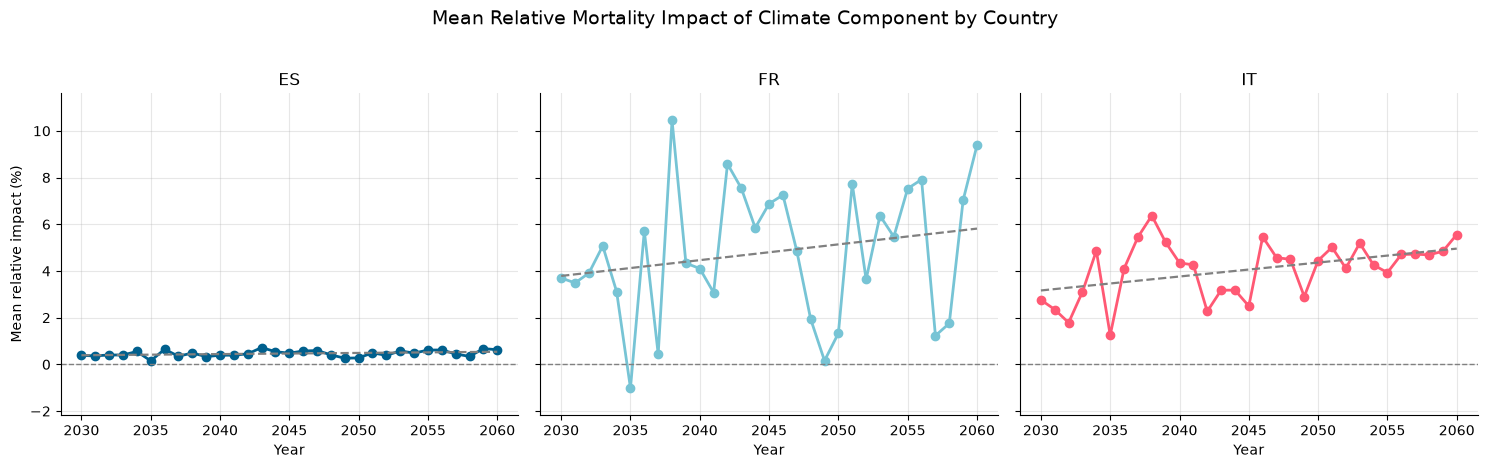

<Figure size 640x480 with 0 Axes>

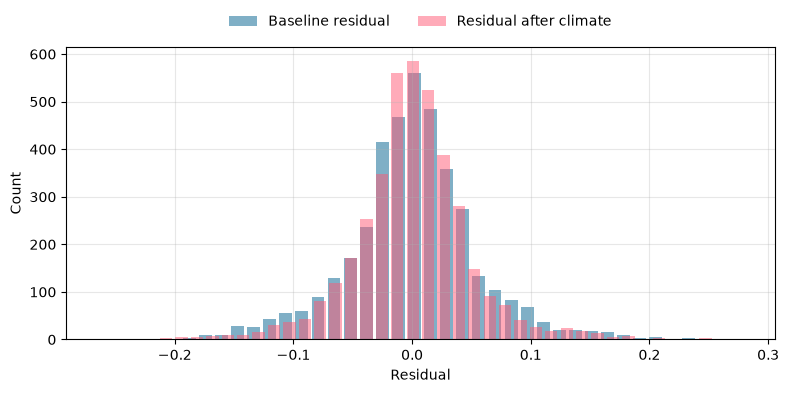

<Figure size 640x480 with 0 Axes>

In [26]:
# Validation plots

PALETTE = {
    "ES": "#00608E",
    "FR": "#77c4d5",
    "IT": "#ff5974",
    "DE": "#fdce07",
    "NL": "#babf33",
}

# Plot 1: base projection impact by country and year.
plot_countries = [c for c in ["ES", "FR", "IT"] if c in COUNTRIES]

if not plot_countries:
    plot_countries = COUNTRIES[: min(3, len(COUNTRIES))]

plot_data = country_year_projection[country_year_projection["country"].isin(plot_countries)].copy()
plot_data["year"] = pd.to_numeric(plot_data["year"], errors="coerce")

if not plot_data.empty and plot_countries:
    fig, axes = plt.subplots(1, len(plot_countries), figsize=(5 * len(plot_countries), 4.5), sharey=True)
    if len(plot_countries) == 1:
        axes = [axes]

    y_min = min(0, plot_data["mean_relative_mx_impact_pct"].min())
    y_max = plot_data["mean_relative_mx_impact_pct"].max()
    y_pad = 0.10 * (y_max - y_min) if y_max > y_min else 0.5

    for ax, country in zip(axes, plot_countries):
        g = plot_data[plot_data["country"].eq(country)].sort_values("year")
        ax.plot(
            g["year"],
            g["mean_relative_mx_impact_pct"],
            marker="o",
            linewidth=2.0,
            color=PALETTE.get(country, "#00608E"),
        )

        # Linear trend line.
        x = g["year"].astype(float).values
        y = g["mean_relative_mx_impact_pct"].astype(float).values
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            slope, intercept = np.polyfit(x[mask], y[mask], 1)
            ax.plot(x[mask], intercept + slope * x[mask], linestyle="--", linewidth=1.6, color="gray")

        ax.axhline(0, linestyle="--", color="gray", linewidth=1.0)
        ax.set_title(country)
        ax.set_xlabel("Year")
        ax.set_xticks(np.arange(PROJECTION_START_YEAR, PROJECTION_END_YEAR + 1, 5))
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.grid(True, alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mean relative impact (%)")
    fig.suptitle("Mean Relative Mortality Impact of Climate Component by Country", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

    plt.savefig(
        OUTPUT_PATH / f"mean_relative_impact_by_country_{SCENARIO}.svg",
        dpi=300,
        bbox_inches="tight"
    )

    print('')

# Plot 2: residual distribution before and after climate calibration.
plt.figure(figsize=(8, 4.5))
plt.hist(
    resid["baseline_residual"].dropna(),
    bins=40,
    alpha=0.5,
    label="Baseline residual",
    color="#00608E",
    rwidth=0.8,
)
plt.hist(
    resid["residual_after_climate"].dropna(),
    bins=40,
    alpha=0.5,
    label="Residual after climate",
    color="#ff5974",
    rwidth=0.8,
)
# plt.title("Residual Distribution Before and After Climate Calibration")  # NOTE: commented out to conform to SOA branding guidelines (title goes above the plot in Word)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)
plt.grid(True, alpha=0.3)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

plt.savefig(
    OUTPUT_PATH / f"residual_distribution_{SCENARIO}.svg",
    dpi=300,
    bbox_inches="tight"
)

## Save Outputs and Output Manifest

In [17]:
# Save Notebook 06 outputs and manifest

output_records = []

def save_dataframe_with_manifest(df, role, path, notes):
    path = Path(path)
    df.to_csv(path, index=False)
    output_records.append(register_file(role, path, notes=notes))
    return path

sensitivity_panel_out = OUTPUT_PATH / f"sensitivity_projection_panel_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
summary_by_experiment_out = OUTPUT_PATH / f"sensitivity_summary_by_experiment_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
summary_country_year_out = OUTPUT_PATH / f"sensitivity_summary_country_year_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
summary_country_age_out = OUTPUT_PATH / f"sensitivity_summary_country_age_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
component_exclusion_delta_summary_out = OUTPUT_PATH / f"component_exclusion_delta_summary_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"

validation_reasonableness_flags_out = OUTPUT_PATH / f"validation_reasonableness_flags_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
validation_reasonableness_flag_summary_out = OUTPUT_PATH / f"validation_reasonableness_flag_summary_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"

residual_validation_out = OUTPUT_PATH / f"residual_validation_diagnostics_{CALIBRATION_YEARS_LABEL}.csv"
residual_overall_out = OUTPUT_PATH / f"residual_validation_overall_{CALIBRATION_YEARS_LABEL}.csv"
gof_overall_out = OUTPUT_PATH / f"residual_gof_overall_{CALIBRATION_YEARS_LABEL}.csv"
gof_by_country_out = OUTPUT_PATH / f"residual_gof_by_country_{CALIBRATION_YEARS_LABEL}.csv"
gof_improvement_by_country_out = OUTPUT_PATH / f"residual_gof_improvement_by_country_{CALIBRATION_YEARS_LABEL}.csv"

climate_index_gof_panel_out = OUTPUT_PATH / f"climate_index_experiment_gof_panel_{CALIBRATION_YEARS_LABEL}.csv"
climate_index_gof_by_experiment_out = OUTPUT_PATH / f"climate_index_experiment_gof_by_experiment_{CALIBRATION_YEARS_LABEL}.csv"
climate_index_gof_improvement_by_experiment_out = OUTPUT_PATH / f"climate_index_experiment_gof_improvement_by_experiment_{CALIBRATION_YEARS_LABEL}.csv"
climate_index_gof_by_experiment_country_out = OUTPUT_PATH / f"climate_index_experiment_gof_by_experiment_country_{CALIBRATION_YEARS_LABEL}.csv"
climate_index_gof_improvement_by_experiment_country_out = OUTPUT_PATH / f"climate_index_experiment_gof_improvement_by_experiment_country_{CALIBRATION_YEARS_LABEL}.csv"
component_exclusion_gof_improvement_out = OUTPUT_PATH / f"component_exclusion_gof_improvement_by_experiment_{CALIBRATION_YEARS_LABEL}.csv"

experiment_definitions_out = OUTPUT_PATH / f"sensitivity_experiment_definitions_{SCENARIO}_{PROJECTION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"

save_dataframe_with_manifest(
    sensitivity_panel,
    "sensitivity_projection_panel",
    sensitivity_panel_out,
    "Projection panel for all Notebook 06 sensitivity experiments, including component exclusion.",
)

save_dataframe_with_manifest(
    summary_by_experiment,
    "sensitivity_summary_by_experiment",
    summary_by_experiment_out,
    "Sensitivity summary by experiment, including delta versus the relevant baseline.",
)

save_dataframe_with_manifest(
    summary_country_year,
    "sensitivity_summary_country_year",
    summary_country_year_out,
    "Sensitivity summary by experiment, country, and projection year.",
)

save_dataframe_with_manifest(
    summary_country_age,
    "sensitivity_summary_country_age",
    summary_country_age_out,
    "Sensitivity summary by experiment, country, and age.",
)

save_dataframe_with_manifest(
    component_exclusion_delta_summary,
    "component_exclusion_delta_summary",
    component_exclusion_delta_summary_out,
    "Focused summary of component-exclusion deltas versus the 20/70/10 baseline.",
)

save_dataframe_with_manifest(
    flags,
    "validation_reasonableness_flags",
    validation_reasonableness_flags_out,
    "Projection reasonableness flags based on the base projection panel.",
)

save_dataframe_with_manifest(
    flag_summary,
    "validation_reasonableness_flag_summary",
    validation_reasonableness_flag_summary_out,
    "Reasonableness flag summary by country and year.",
)

save_dataframe_with_manifest(
    residual_validation,
    "residual_validation_diagnostics",
    residual_validation_out,
    "Residual validation diagnostics by country and year.",
)

save_dataframe_with_manifest(
    residual_overall,
    "residual_validation_overall",
    residual_overall_out,
    "Overall residual validation metrics.",
)

save_dataframe_with_manifest(
    gof_overall,
    "residual_gof_overall",
    gof_overall_out,
    "Overall residual goodness-of-fit metrics.",
)

save_dataframe_with_manifest(
    gof_by_country,
    "residual_gof_by_country",
    gof_by_country_out,
    "Residual goodness-of-fit metrics by country.",
)

save_dataframe_with_manifest(
    gof_improvement_by_country,
    "residual_gof_improvement_by_country",
    gof_improvement_by_country_out,
    "Residual goodness-of-fit improvement metrics by country.",
)

save_dataframe_with_manifest(
    weight_gof_panel,
    "climate_index_experiment_gof_panel",
    climate_index_gof_panel_out,
    "Historical residual panel for climate-index weight and component-exclusion GOF tests.",
)

save_dataframe_with_manifest(
    weight_gof_by_experiment,
    "climate_index_experiment_gof_by_experiment",
    climate_index_gof_by_experiment_out,
    "Goodness-of-fit metrics by climate-index experiment.",
)

save_dataframe_with_manifest(
    weight_gof_improvement_by_experiment,
    "climate_index_experiment_gof_improvement_by_experiment",
    climate_index_gof_improvement_by_experiment_out,
    "Goodness-of-fit improvement by climate-index experiment.",
)

save_dataframe_with_manifest(
    weight_gof_by_experiment_country,
    "climate_index_experiment_gof_by_experiment_country",
    climate_index_gof_by_experiment_country_out,
    "Goodness-of-fit metrics by climate-index experiment and country.",
)

save_dataframe_with_manifest(
    weight_gof_improvement_by_experiment_country,
    "climate_index_experiment_gof_improvement_by_experiment_country",
    climate_index_gof_improvement_by_experiment_country_out,
    "Goodness-of-fit improvement by climate-index experiment and country.",
)

save_dataframe_with_manifest(
    component_exclusion_gof_improvement_by_experiment,
    "component_exclusion_gof_improvement_by_experiment",
    component_exclusion_gof_improvement_out,
    "Focused goodness-of-fit improvement table for component-exclusion experiments.",
)

save_dataframe_with_manifest(
    experiment_definitions,
    "sensitivity_experiment_definitions",
    experiment_definitions_out,
    "Definitions of all Notebook 06 sensitivity experiments.",
)

notebook6_output_manifest = pd.DataFrame(output_records)
notebook6_output_manifest.to_csv(notebook6_output_manifest_file, index=False)

print("Notebook 06 outputs saved.")
print(f"Output manifest: {PureWindowsPath(notebook6_output_manifest_file).name}")

# Create report
subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        str(NOTEBOOK_FILE),
        "--to",
        "html",
        "--no-input",
        "--output-dir",
        str(REPORTS_PATH),
    ],
    check=True,
)

Notebook 06 outputs saved.
Output manifest: 06_sensitivity_and_validation_output_manifest.csv


CompletedProcess(args=['c:\\venvs\\CC230\\Scripts\\python.exe', '-m', 'jupyter', 'nbconvert', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230-Toolkit\\notebooks\\06_sensitivity_and_validation.ipynb', '--to', 'html', '--no-input', '--output-dir', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230-Toolkit\\reports'], returncode=0)